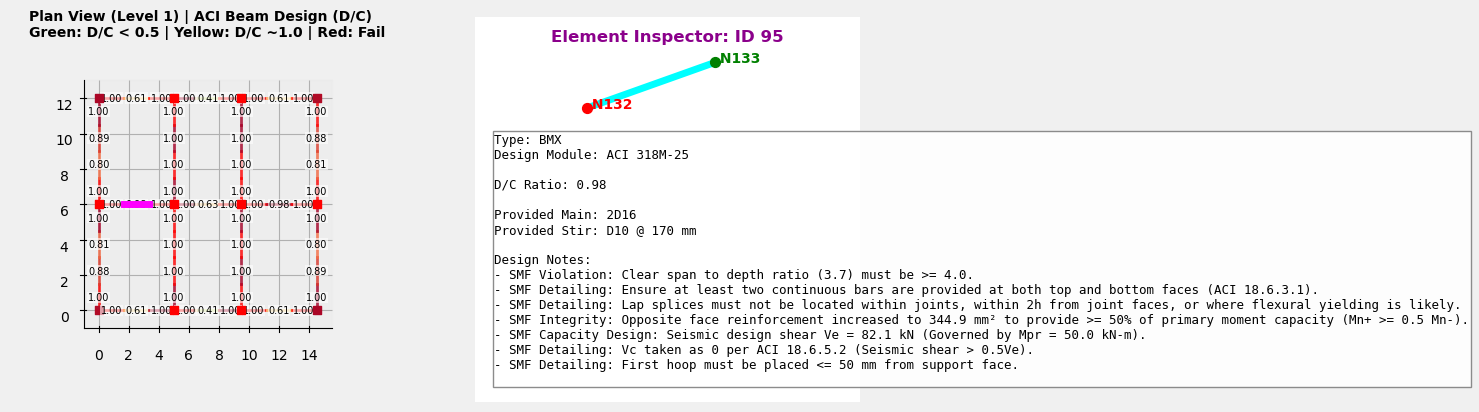

In [1]:
import FreeSimpleGUI as sg
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import openseespy.opensees as ops
import numpy as np
import math

# === Import the ACI 318M-25 Design Libraries ===
from aci318m25 import MaterialProperties
from aci318m25_beam import ACI318M25BeamDesign, BeamGeometry, BeamType, SeismicDesignCategory as BeamSDC, FrameSystem as BeamFS
from aci318m25_column import ACI318M25ColumnDesign, ColumnGeometry, ColumnLoads, ColumnShape, ColumnType, LoadCondition, SeismicDesignCategory as ColSDC, FrameSystem as ColFS
from aci318m25_slab import ACI318M25SlabDesign, SlabGeometry, SlabLoads, SlabType, SupportCondition, LoadPattern
from aci318m25_footing import ACI318M25FootingDesign, FootingGeometry, FootingLoads, SoilProperties, FootingType, SoilCondition

# ==========================================
# Helper: Matplotlib Interactive Embedding
# ==========================================
def draw_figure(window, figure, ele_centers=None, ax_main=None):
    canvas = window["-CANVAS-"].TKCanvas
    if canvas.children:
        for child in canvas.winfo_children(): child.destroy()
    figure_canvas_agg = FigureCanvasTkAgg(figure, canvas)
    figure_canvas_agg.draw()
    figure_canvas_agg.get_tk_widget().pack(side='top', fill='both', expand=1)

    if ele_centers and ax_main:
        from mpl_toolkits.mplot3d import proj3d
        def onclick(event):
            if event.inaxes != ax_main: return
            min_dist = 15 
            closest_tag = None
            for tag, pt in ele_centers.items():
                x2, y2, _ = proj3d.proj_transform(*pt, ax_main.get_proj())
                disp_pt = ax_main.transData.transform((x2, y2))
                dist = np.hypot(event.x - disp_pt[0], event.y - disp_pt[1])
                if dist < min_dist:
                    min_dist, closest_tag = dist, tag
            if closest_tag:
                window.write_event_value("-SELECT_ELE-", closest_tag)
        figure.canvas.mpl_connect('button_press_event', onclick)
    return figure_canvas_agg

def discretize_axis(spacings, target_size=0.5):
    coords = [0.0]; col_indices = [0]
    for dx in spacings:
        n = max(1, int(round(dx / target_size)))
        step = dx / n
        for _ in range(n): coords.append(coords[-1] + step)
        col_indices.append(len(coords) - 1)
    return coords, col_indices

# ==========================================
# Helper: ACI 318M-25 Automation Engine
# ==========================================
def run_aci_design(geom_data, strength_env, service_env, qa_val, sdc_val, frame_sys_val):
    node_coords, ele_info = geom_data[0], geom_data[1]
    aci_results = {}
    
    beam_designer = ACI318M25BeamDesign()
    col_designer = ACI318M25ColumnDesign()
    slab_designer = ACI318M25SlabDesign()
    foot_designer = ACI318M25FootingDesign()
    
    fs_str = frame_sys_val.lower()
    beam_sdc = BeamSDC[sdc_val]
    beam_fs = BeamFS(fs_str)
    col_sdc = ColSDC[sdc_val]
    col_fs = ColFS(fs_str)
    
    # 1. Frame and Shell Design
    for tag, info in ele_info.items():
        F = strength_env['ele_forces'][tag]
        mat = MaterialProperties(
            fc_prime=info.get('fc', 28.0), fy=info.get('fy', 414.0), fu=info.get('fy', 414.0)*1.25, 
            es=200000.0, ec=4700*math.sqrt(info.get('fc', 28.0)), gamma_c=24.0, description="Auto Assigned"
        )
        
        if info['type'] == 'shell':
            Mux, Muy = abs(F[3]) + abs(F[5]), abs(F[4]) + abs(F[5])
            try:
                bar_x, spacing_x = slab_designer.design_flexural_reinforcement(
                    moment=Mux, width=1000.0, effective_depth=info['t']-30.0, thickness=info['t'], cover=20.0, material_props=mat
                )
                bar_y, spacing_y = slab_designer.design_flexural_reinforcement(
                    moment=Muy, width=1000.0, effective_depth=info['t']-40.0, thickness=info['t'], cover=20.0, material_props=mat
                )
                As_x = slab_designer.aci.get_bar_area(bar_x) * 1000.0 / spacing_x
                As_y = slab_designer.aci.get_bar_area(bar_y) * 1000.0 / spacing_y
                phi_Mn_x = 0.90 * As_x * mat.fy * ((info['t']-30.0) - ((As_x * mat.fy)/(0.85 * mat.fc_prime * 1000.0))/2.0) / 1e6
                phi_Mn_y = 0.90 * As_y * mat.fy * ((info['t']-40.0) - ((As_y * mat.fy)/(0.85 * mat.fc_prime * 1000.0))/2.0) / 1e6
                util_x, util_y = Mux / phi_Mn_x if phi_Mn_x > 0 else 9.99, Muy / phi_Mn_y if phi_Mn_y > 0 else 9.99
                
                aci_results[tag] = {
                    'bar_x': bar_x, 'spacing_x': spacing_x, 'bar_y': bar_y, 'spacing_y': spacing_y,
                    'utilization_ratio': max(util_x, util_y), 'Mux': Mux, 'Muy': Muy,
                    'design_notes': [f"Wood-Armer Mux: {Mux:.1f} kNm/m", f"Wood-Armer Muy: {Muy:.1f} kNm/m"]
                }
            except Exception as e:
                aci_results[tag] = {'error': str(e), 'utilization_ratio': 9.99, 'design_notes': [str(e)]}
            continue

        n1, n2 = info['n1'], info['n2']
        L = np.linalg.norm(node_coords[n2] - node_coords[n1]) * 1000 
        
        if info['type'] in ['bmX', 'bmY']:
            Mu, Vu, Tu = max(abs(F[4]), abs(F[10]), abs(F[5]), abs(F[11])), max(abs(F[2]), abs(F[8]), abs(F[1]), abs(F[7])), max(abs(F[3]), abs(F[9]))
            
            col_w1, col_w2 = 400.0, 400.0
            for t_c, inf_c in ele_info.items():
                if inf_c['type'] == 'col':
                    if inf_c['n1'] == n1 or inf_c['n2'] == n1: col_w1 = inf_c['cx']
                    if inf_c['n1'] == n2 or inf_c['n2'] == n2: col_w2 = inf_c['cx']
            clear_span = L - (col_w1/2.0 + col_w2/2.0)
            
            bg = BeamGeometry(
                length=L, width=info['b'], height=info['h'], effective_depth=info['h']-60,
                cover=40, flange_width=0, flange_thickness=0, beam_type=BeamType.RECTANGULAR,
                clear_span=clear_span, sdc=beam_sdc, frame_system=beam_fs
            )
            try: aci_results[tag] = beam_designer.perform_complete_beam_design(mu=Mu, vu=Vu, beam_geometry=bg, material_props=mat, tu=Tu)
            except Exception as e: aci_results[tag] = {'error': str(e), 'utilization_ratio': 9.99, 'design_notes': [str(e)]}
                
        elif info['type'] == 'col':
            Pu, Mux, Muy = max(abs(F[0]), abs(F[6])), max(abs(F[4]), abs(F[10])), max(abs(F[5]), abs(F[11]))
            Vux, Vuy = max(abs(F[1]), abs(F[7])), max(abs(F[2]), abs(F[8]))
            cg = ColumnGeometry(
                width=info['cx'], depth=info['cy'], height=L, clear_height=L-info['h'],
                cover=40, shape=ColumnShape.RECTANGULAR, column_type=ColumnType.TIED, effective_length=L,
                sdc=col_sdc, frame_system=col_fs
            )
            cl = ColumnLoads(axial_force=Pu, moment_x=Mux, moment_y=Muy, shear_x=Vux, shear_y=Vuy, load_condition=LoadCondition.BIAXIAL_BENDING)
            try: aci_results[tag] = col_designer.perform_complete_column_design(cl, cg, mat)
            except Exception as e: aci_results[tag] = {'error': str(e), 'utilization_ratio': 9.99, 'design_notes': [str(e)]}
                
    # 2. Footing Design
    mat_foot = MaterialProperties(fc_prime=28.0, fy=414.0, fu=414.0*1.25, es=200000.0, ec=4700*math.sqrt(28.0), gamma_c=24.0, description="Foundation")
    soil_props = SoilProperties(bearing_capacity=qa_val, unit_weight=18.0, friction_angle=30, cohesion=0, condition=SoilCondition.ALLOWABLE_STRESS)
    
    z_base = min(coord[2] for coord in node_coords.values())
    base_col_nodes = set()
    for info in ele_info.values():
        if info['type'] == 'col':
            if abs(node_coords[info['n1']][2] - z_base) < 1e-4: base_col_nodes.add(info['n1'])
            if abs(node_coords[info['n2']][2] - z_base) < 1e-4: base_col_nodes.add(info['n2'])
            
    for node_tag in base_col_nodes:
        str_R = strength_env['react'].get(node_tag, [0]*6)
        srv_R = service_env['react'].get(node_tag, [0]*6)
        
        Pu, Mux, Muy = abs(str_R[2]), abs(str_R[3]), abs(str_R[4])
        Vux, Vuy = abs(str_R[0]), abs(str_R[1])
        P_srv, Mx_srv, My_srv = abs(srv_R[2]), abs(srv_R[3]), abs(srv_R[4])
        
        col_cx, col_cy = 400.0, 400.0
        for info in ele_info.values():
            if info['type'] == 'col' and (info['n1'] == node_tag or info['n2'] == node_tag):
                col_cx, col_cy = info['cx'], info['cy']
                break
        
        f_loads = FootingLoads(
            axial_force=Pu, moment_x=Mux, moment_y=Muy, shear_x=Vux, shear_y=Vuy,
            service_axial=P_srv, service_moment_x=Mx_srv, service_moment_y=My_srv
        )
        init_geom = FootingGeometry(
            length=1500.0, width=1500.0, thickness=350.0, cover=75.0, 
            column_width=col_cx, column_depth=col_cy, footing_type=FootingType.ISOLATED_SQUARE
        )
        try:
            res = foot_designer.perform_complete_footing_design(loads=f_loads, soil_props=soil_props, material_props=mat_foot, initial_geometry=init_geom)
            aci_results[f"Node_{node_tag}"] = res
        except Exception as e:
            aci_results[f"Node_{node_tag}"] = {'error': str(e), 'utilization_ratio': 9.99, 'design_notes': [str(e)]}

    # === NEW: QUANTITY TAKEOFF (QTO) CALCULATOR ===
    def generate_qto(ele_info, node_coords, aci_res):
        qto = {'cfa': 0.0, 'vol_c': 0.0, 'wt_s': 0.0, 'area_f': 0.0}
        bars = {'D10': 78.54, 'D12': 113.10, 'D16': 201.06, 'D20': 314.16,
                'D25': 490.87, 'D28': 615.75, 'D32': 804.25, 'D36': 1017.88,
                'D40': 1256.64, 'D50': 1963.50, 'None': 0.0, '': 0.0}
        
        for tag, info in ele_info.items():
            if info['type'] == 'shell':
                pts = [node_coords[n] for n in info['nodes']]
                L1 = np.linalg.norm(pts[1] - pts[0]) * 1000
                L2 = np.linalg.norm(pts[3] - pts[0]) * 1000
                area_m2 = (L1 * L2) / 1e6
                t_mm = info['t']
                
                qto['cfa'] += area_m2
                qto['vol_c'] += area_m2 * (t_mm / 1000.0)
                qto['area_f'] += area_m2 
                
                if tag in aci_res and isinstance(aci_res[tag], dict) and 'bar_x' in aci_res[tag]:
                    res = aci_res[tag]
                    As_x = bars.get(res['bar_x'], 0) * 1000 / res['spacing_x'] if res['spacing_x']>0 else 0
                    As_y = bars.get(res['bar_y'], 0) * 1000 / res['spacing_y'] if res['spacing_y']>0 else 0
                    qto['wt_s'] += area_m2 * (As_x + As_y) * 1e-6 * 7850
                    
            elif info['type'] == 'col':
                L_mm = np.linalg.norm(node_coords[info['n2']] - node_coords[info['n1']]) * 1000
                cx, cy = info['cx'], info['cy']
                Lc = max(0, L_mm - 400.0)
                qto['vol_c'] += (cx * cy * Lc) / 1e9
                qto['area_f'] += (2 * (cx + cy) * Lc) / 1e6
                
                if tag in aci_res and not isinstance(aci_res[tag], dict):
                    reinf = aci_res[tag].reinforcement
                    qto['wt_s'] += (reinf.longitudinal_area * L_mm) / 1e9 * 7850
                    tie_area = bars.get(reinf.tie_bars, 78.54)
                    num_ties = L_mm / reinf.tie_spacing if reinf.tie_spacing > 0 else 0
                    tie_len = 2 * (cx + cy)
                    qto['wt_s'] += (tie_area * tie_len * num_ties) / 1e9 * 7850
                    
            elif info['type'] in ['bmX', 'bmY']:
                L_mm = np.linalg.norm(node_coords[info['n2']] - node_coords[info['n1']]) * 1000
                b, h = info['b'], info['h']
                Lc = max(0, L_mm - 400.0)
                hw = max(0, h - 150.0)
                qto['vol_c'] += (b * hw * Lc) / 1e9
                qto['area_f'] += ((2 * hw + b) * Lc) / 1e6
                
                if tag in aci_res and not isinstance(aci_res[tag], dict):
                    reinf = aci_res[tag].reinforcement
                    main_area = sum(bars.get(bar, 0) for bar in reinf.main_bars)
                    qto['wt_s'] += (main_area * L_mm) / 1e9 * 7850
                    stir_area = 2 * bars.get(reinf.stirrups, 78.54) 
                    num_stir = L_mm / reinf.stirrup_spacing if reinf.stirrup_spacing > 0 else 0
                    stir_len = 2 * (b + h)
                    qto['wt_s'] += (stir_area * stir_len * num_stir) / 1e9 * 7850

        for key, res in aci_res.items():
            if str(key).startswith('Node_') and not isinstance(res, dict):
                Lf, Wf, Tf = res.final_length, res.final_width, res.final_thickness
                qto['vol_c'] += (Lf * Wf * Tf) / 1e9
                qto['area_f'] += (2 * (Lf + Wf) * Tf) / 1e6
                reinf = res.reinforcement
                As_x = bars.get(reinf.bottom_bars_x, 0)
                As_y = bars.get(reinf.bottom_bars_y, 0)
                nx = Wf / reinf.bottom_spacing_x if reinf.bottom_spacing_x > 0 else 0
                ny = Lf / reinf.bottom_spacing_y if reinf.bottom_spacing_y > 0 else 0
                qto['wt_s'] += (As_x * Lf * nx + As_y * Wf * ny) / 1e9 * 7850
                
        return qto

    aci_results['qto_report'] = generate_qto(ele_info, node_coords, aci_results)
    return aci_results

def calculate_envelope(combo_keys, results_dict):
    env = {'disp': {}, 'react': {}, 'ele_forces': {}}
    if not combo_keys: return env
    first_key = combo_keys[0]
    for tag in results_dict[first_key]['disp'].keys():
        arr = np.array([results_dict[k]['disp'][tag] for k in combo_keys])
        env['disp'][tag] = arr[np.argmax(np.abs(arr), axis=0), np.arange(arr.shape[1])].tolist()
    for tag in results_dict[first_key]['react'].keys():
        arr = np.array([results_dict[k]['react'][tag] for k in combo_keys])
        env['react'][tag] = arr[np.argmax(np.abs(arr), axis=0), np.arange(arr.shape[1])].tolist()
    for tag in results_dict[first_key]['ele_forces'].keys():
        arr = np.array([results_dict[k]['ele_forces'][tag] for k in combo_keys])
        env['ele_forces'][tag] = arr[np.argmax(np.abs(arr), axis=0), np.arange(arr.shape[1])].tolist()
    return env

# ==========================================
# Helper: OpenSeesPy Analysis Engine
# ==========================================
def run_opensees_analysis(data, progress_cb=None):
    def update(pct, msg):
        if progress_cb: progress_cb(pct, msg)

    floors = data['floors']
    foundation_elev = data.get('foundation_elev', 0.0)
    z_coords = sorted(list(set([foundation_elev] + [float(f['Elevation_m']) for f in floors])))
    Nz = len(z_coords)
    active_z = [z for z in z_coords if z > 0.01]
    h_roof = max(active_z) if active_z else 0.0
    Bx, By = sum(data['x_bays_m']), sum(data['y_bays_m'])

    update(5, "Calculating Wind Profile (Superstructure Only)...")
    V_kph, expo = data['wind_v'], data['wind_exp']
    V_ms = V_kph / 3.6
    if expo == 'B': zg, alpha = 365.76, 7.0
    elif expo == 'C': zg, alpha = 274.32, 9.5
    else: zg, alpha = 213.36, 11.5 
    
    def calc_qz(z): return 0.613 * (2.01 * (max(z, 4.5) / zg) ** (2.0 / alpha)) * 1.0 * 0.85 * (V_ms**2) / 1000.0
    qh, G, Cp_ww, Cp_sw = calc_qz(h_roof) if h_roof > 0 else 0.0, 0.85, 0.8, -0.7
    def get_cp_lw(L, B):
        r = L / B
        if r <= 1.0: return -0.5
        elif r >= 4.0: return -0.2
        else: return -0.5 + (r - 1.0) * 0.1 
    Cp_lw_x, Cp_lw_y = get_cp_lw(Bx, By), get_cp_lw(By, Bx) 
    
    wind_report, story_forces, nodal_wx, nodal_wy = [], [], {}, {}
    for k in range(1, Nz):
        z = z_coords[k]
        if z <= 0.01:
            wind_report.append({'Level': k, 'z': z, 'qz': 0, 'p_ww_x': 0, 'p_lw_x': 0, 'p_sw_x': 0, 'p_ww_y': 0, 'p_lw_y': 0, 'p_sw_y': 0})
            story_forces.append({'Level': k, 'Fx': 0, 'Fy': 0, 'C2X': 0, 'M2X': 0, 'C3X': 0, 'C4X': 0, 'M4': 0})
            continue

        qz = calc_qz(z)
        p_ww_x, p_lw_x, p_sw_x = qz*G*Cp_ww, qh*G*Cp_lw_x, qh*G*Cp_sw
        p_ww_y, p_lw_y, p_sw_y = qz*G*Cp_ww, qh*G*Cp_lw_y, qh*G*Cp_sw
        wind_report.append({'Level': k, 'z': z, 'qz': qz, 'p_ww_x': p_ww_x, 'p_lw_x': p_lw_x, 'p_sw_x': p_sw_x, 'p_ww_y': p_ww_y, 'p_lw_y': p_lw_y, 'p_sw_y': p_sw_y})
        z_below = max(0.0, z_coords[k-1])
        z_above = z_coords[k+1] if k < Nz-1 else z
        h_trib = (z - z_below)/2.0 + (z_above - z)/2.0
        Fx, Fy = (p_ww_x - p_lw_x) * By * h_trib, (p_ww_y - p_lw_y) * Bx * h_trib
        eX, eY = 0.15 * Bx, 0.15 * By
        story_forces.append({'Level': k, 'Fx': Fx, 'Fy': Fy, 'C2X': 0.75 * Fx, 'M2X': 0.75 * Fx * eY, 'C3X': 0.75 * Fx, 'C4X': 0.563 * Fx, 'M4': 0.563*Fx*eY + 0.563*Fy*eX})

    x_mesh, col_x = discretize_axis(data['x_bays_m'], data['mesh_size'])
    y_mesh, col_y = discretize_axis(data['y_bays_m'], data['mesh_size'])
    Nx, Ny = len(x_mesh), len(y_mesh)
    x_c = [0.0]; [x_c.append(x_c[-1] + dx) for dx in data['x_bays_m']]
    y_c = [0.0]; [y_c.append(y_c[-1] + dy) for dy in data['y_bays_m']]
    
    for k in range(1, Nz):
        if z_coords[k] <= 0.01: continue 
        f_idx = min(k-1, len(floors)-1)
        f = floors[f_idx]; Ec = 4700 * (f['fcp_MPa'] ** 0.5) * 1000 
        cx, cy = f['Col_cx_mm']/1000.0, f['Col_cy_mm']/1000.0
        Iy_col_cr, Iz_col_cr = (cy * cx**3 / 12.0) * 0.70, (cx * cy**3 / 12.0) * 0.70
        L_col = z_coords[k] - z_coords[k-1]
        kx, ky = 12.0 * Ec * Iy_col_cr / (L_col**3), 12.0 * Ec * Iz_col_cr / (L_col**3)
        Kx_total, Ky_total = kx * len(x_c) * len(y_c), ky * len(x_c) * len(y_c)
        X_cr, Y_cr = sum([x * ky for x in x_c for y in y_c]) / Ky_total, sum([y * kx for x in x_c for y in y_c]) / Kx_total
        Jr = sum([kx * (y - Y_cr)**2 + ky * (x - X_cr)**2 for x in x_c for y in y_c])
        X_cg, Y_cg = Bx / 2.0, By / 2.0
        
        Fx_story, Fy_story = story_forces[k-1]['Fx'], story_forces[k-1]['Fy']
        Mt_X, Mt_Y = Fx_story * (Y_cg - Y_cr), -Fy_story * (X_cg - X_cr)
        
        for ix, x in enumerate(x_c):
            for iy, y in enumerate(y_c):
                nodal_wx[(ix, iy, k)] = Fx_story * (kx / Kx_total) - Mt_X * ((y - Y_cr) / Jr) * kx
                nodal_wy[(ix, iy, k)] = Fy_story * (ky / Ky_total) + Mt_Y * ((x - X_cr) / Jr) * ky

    update(15, "Building Engine & Geometry...")
    ops.wipe(); ops.model('basic', '-ndm', 3, '-ndf', 6)
    
    def get_node(i, j, k): return k * (Nx * Ny) + j * Nx + i + 1
    node_coords = {}
    
    for k in range(Nz):
        for j in range(Ny):
            for i in range(Nx):
                tag = get_node(i, j, k)
                ops.node(tag, x_mesh[i], y_mesh[j], z_coords[k])
                node_coords[tag] = np.array([x_mesh[i], y_mesh[j], z_coords[k]])
                if k == 0:
                    if (i in col_x) and (j in col_y):
                        if data['base_supports'] == 'Fixed': ops.fix(tag, 1, 1, 1, 1, 1, 1) 
                        else: ops.fix(tag, 1, 1, 1, 0, 0, 1) 
                    else: ops.fix(tag, 1, 1, 1, 1, 1, 1) 
                else: ops.fix(tag, 0, 0, 0, 0, 0, 1) 

    ops.geomTransf('PDelta', 1, 0, 1, 0); ops.geomTransf('Linear', 2, 0, 0, 1); ops.geomTransf('Linear', 3, 0, 0, 1)

    update(20, "Assigning Discretized Dead Loads...")
    ele_tag = 1; ele_info = {}
    node_DL = {get_node(i,j,k): 0.0 for k in range(Nz) for j in range(Ny) for i in range(Nx)}
    node_LL = {get_node(i,j,k): 0.0 for k in range(Nz) for j in range(Ny) for i in range(Nx)}

    for k in range(1, Nz):
        f_idx = min(k-1, len(floors)-1)
        f = floors[f_idx]
        Ec = 4700 * (f['fcp_MPa'] ** 0.5) * 1000; G = Ec / 2.4
        b, h, cx, cy, st = f['Beam_b_mm']/1000, f['Beam_h_mm']/1000, f['Col_cx_mm']/1000, f['Col_cy_mm']/1000, f['Slab_t_mm']/1000
        A_col, Iy_col, Iz_col = cx*cy, cy*cx**3/12, cx*cy**3/12
        A_bm, Iy_bm, Iz_bm = b*h, b*h**3/12, h*b**3/12
        Iy_col_cr, Iz_col_cr = Iy_col * 0.70, Iz_col * 0.70
        Iy_bm_cr, Iz_bm_cr = Iy_bm * 0.35, Iz_bm * 0.35
        E_slab_cr = Ec * 0.25 
        w_col, w_bm = A_col*24.0, A_bm*24.0
        a_dl, a_ll = f['SDL_kPa'] + (st*24.0), f['LL_kPa']
        fh = z_coords[k] - z_coords[k-1]

        sec_tag = k
        ops.section('ElasticMembranePlateSection', sec_tag, E_slab_cr, 0.2, st, 0.0)
        
        for j in range(Ny-1):
            for i in range(Nx-1):
                n1, n2, n3, n4 = get_node(i,j,k), get_node(i+1,j,k), get_node(i+1,j+1,k), get_node(i,j+1,k)
                ops.element('ShellMITC4', ele_tag, n1, n2, n3, n4, sec_tag)
                ele_info[ele_tag] = {'type': 'shell', 'nodes': [n1, n2, n3, n4], 't': st*1000, 'fc': f['fcp_MPa'], 'fy': f['fy_MPa']}
                ele_tag += 1
                dx = x_mesh[i+1] - x_mesh[i]; dy = y_mesh[j+1] - y_mesh[j]; area = dx * dy
                for n in [n1, n2, n3, n4]:
                    node_DL[n] += (a_dl * area) / 4.0; node_LL[n] += (a_ll * area) / 4.0

        for idx_y, j in enumerate(col_y):
            for idx_x, i in enumerate(col_x):
                n1, n2 = get_node(i,j,k-1), get_node(i,j,k)
                ops.element('elasticBeamColumn', ele_tag, n1, n2, A_col, Ec, G, Iy_col_cr+Iz_col_cr, Iy_col_cr, Iz_col_cr, 1)
                ele_info[ele_tag] = {'type': 'col', 'n1': n1, 'n2': n2, 'cx': cx*1000, 'cy': cy*1000, 'h': h*1000, 'fc': f['fcp_MPa'], 'fy': f['fy_MPa']}
                ele_tag += 1
                node_DL[n1] += w_col * fh / 2.0; node_DL[n2] += w_col * fh / 2.0

        for j in col_y:
            for i in range(Nx-1):
                n1, n2 = get_node(i,j,k), get_node(i+1,j,k)
                ops.element('elasticBeamColumn', ele_tag, n1, n2, A_bm, Ec, G, Iy_bm_cr+Iz_bm_cr, Iy_bm_cr, Iz_bm_cr, 2)
                ele_info[ele_tag] = {'type': 'bmX', 'n1': n1, 'n2': n2, 'w_dl': w_bm, 'b': b*1000, 'h': h*1000, 'fc': f['fcp_MPa'], 'fy': f['fy_MPa']}
                ele_tag += 1
                length = x_mesh[i+1] - x_mesh[i]
                node_DL[n1] += w_bm * length / 2.0; node_DL[n2] += w_bm * length / 2.0

        for i in col_x:
            for j in range(Ny-1):
                n1, n2 = get_node(i,j,k), get_node(i,j+1,k)
                ops.element('elasticBeamColumn', ele_tag, n1, n2, A_bm, Ec, G, Iy_bm_cr+Iz_bm_cr, Iy_bm_cr, Iz_bm_cr, 3)
                ele_info[ele_tag] = {'type': 'bmY', 'n1': n1, 'n2': n2, 'w_dl': w_bm, 'b': b*1000, 'h': h*1000, 'fc': f['fcp_MPa'], 'fy': f['fy_MPa']}
                ele_tag += 1
                length = y_mesh[j+1] - y_mesh[j]
                node_DL[n1] += w_bm * length / 2.0; node_DL[n2] += w_bm * length / 2.0

    update(30, "Running Modal Analysis...")
    floor_masses = {k: 0.0 for k in range(1, Nz)}
    for tag, dl in node_DL.items():
        mass = dl / 9.81 
        if mass > 0:
            ops.mass(tag, mass, mass, mass, 1e-6, 1e-6, 1e-6)
            for k in range(1, Nz):
                if abs(node_coords[tag][2] - z_coords[k]) < 0.01:
                    floor_masses[k] += mass; break

    for tag, info in ele_info.items():
        if info['type'] in ['bmX', 'bmY']:
            L = np.linalg.norm(node_coords[info['n2']] - node_coords[info['n1']])
            mass_half = (info['w_dl'] * L / 2.0) / 9.81
            for n in [info['n1'], info['n2']]:
                ops.mass(n, mass_half, mass_half, mass_half, 1e-6, 1e-6, 1e-6)
                for k in range(1, Nz):
                    if abs(node_coords[n][2] - z_coords[k]) < 0.01:
                        floor_masses[k] += mass_half; break

    num_modes = int(data.get('num_modes', 6))
    try: eigen_values = ops.eigen('-genBandArpack', num_modes)
    except: eigen_values = ops.eigen(num_modes)
    
    modal_data = {'periods': [], 'shapes': {m: {'disp': {}} for m in range(1, num_modes+1)}}
    phi_x = {m: {k: 0.0 for k in range(1, Nz)} for m in range(1, num_modes+1)}
    phi_y = {m: {k: 0.0 for k in range(1, Nz)} for m in range(1, num_modes+1)}
    gamma_x_list, gamma_y_list = [], []

    active_k = [k for k in range(1, Nz) if z_coords[k] > 0.01]

    for i, lam in enumerate(eigen_values):
        T = 2 * np.pi / np.sqrt(lam) if lam > 0 else 0.0
        modal_data['periods'].append(T)
        m = i + 1
        for k in range(1, Nz):
            ux_s = 0; uy_s = 0; count = 0
            for j in range(Ny):
                for ix in range(Nx):
                    tag = get_node(ix, j, k)
                    d_x, d_y, d_z = ops.nodeEigenvector(tag, m, 1), ops.nodeEigenvector(tag, m, 2), ops.nodeEigenvector(tag, m, 3)
                    ux_s += d_x; uy_s += d_y; count += 1
                    modal_data['shapes'][m]['disp'][tag] = [d_x, d_y, d_z]
            phi_x[m][k] = ux_s / count if count > 0 else 0
            phi_y[m][k] = uy_s / count if count > 0 else 0
            
        num_x = sum(floor_masses[k] * phi_x[m][k] for k in active_k) if active_k else 0.0
        den_x = sum(floor_masses[k] * phi_x[m][k]**2 for k in active_k) if active_k else 1.0
        num_y = sum(floor_masses[k] * phi_y[m][k] for k in active_k) if active_k else 0.0
        den_y = sum(floor_masses[k] * phi_y[m][k]**2 for k in active_k) if active_k else 1.0
        gamma_x_list.append(num_x / den_x)
        gamma_y_list.append(num_y / den_y)

    update(35, "Evaluating RSA Spectrum & ELF Scaling...")
    Ca, Cv, R_factor, I_factor = data['Ca'], data['Cv'], data['R'], data['I']
    Ts = Cv / (2.5 * Ca) if Ca > 0 else 0; T0 = 0.2 * Ts
    def get_Sa(T):
        if T < T0: return Ca * (1 + 1.5 * T / T0)
        elif T <= Ts: return 2.5 * Ca
        else: return Cv / T
        
    V_modal_x = {m: {k: 0.0 for k in range(1, Nz)} for m in range(1, num_modes+1)}
    V_modal_y = {m: {k: 0.0 for k in range(1, Nz)} for m in range(1, num_modes+1)}
    for m in range(1, num_modes+1):
        Sa = get_Sa(modal_data['periods'][m-1])
        gamma_x, gamma_y = gamma_x_list[m-1], gamma_y_list[m-1]
        
        Fx_m_dict = {k: 0.0 for k in range(1, Nz)}
        Fy_m_dict = {k: 0.0 for k in range(1, Nz)}
        
        for k in active_k:
            Fx_m_dict[k] = gamma_x * floor_masses[k] * phi_x[m][k] * (Sa * 9.81) * (I_factor / R_factor)
            Fy_m_dict[k] = gamma_y * floor_masses[k] * phi_y[m][k] * (Sa * 9.81) * (I_factor / R_factor)
            
        for k in range(1, Nz):
            V_modal_x[m][k] = sum(Fx_m_dict[i] for i in range(k, Nz)) 
            V_modal_y[m][k] = sum(Fy_m_dict[i] for i in range(k, Nz))
            
    V_srss_x = {k: np.sqrt(sum(V_modal_x[m][k]**2 for m in range(1, num_modes+1))) for k in range(1, Nz)}
    V_srss_y = {k: np.sqrt(sum(V_modal_y[m][k]**2 for m in range(1, num_modes+1))) for k in range(1, Nz)}
    F_srss_x = {k: V_srss_x[k] - (V_srss_x[k+1] if k < Nz-1 else 0) for k in range(1, Nz)}
    F_srss_y = {k: V_srss_y[k] - (V_srss_y[k+1] if k < Nz-1 else 0) for k in range(1, Nz)}

    dom_x_idx, dom_y_idx = np.argmax(np.abs(gamma_x_list)), np.argmax(np.abs(gamma_y_list))
    Tx, Ty = modal_data['periods'][dom_x_idx], modal_data['periods'][dom_y_idx]
    
    W_total = sum(floor_masses[k] for k in active_k) * 9.81 if active_k else 0.0
    
    def get_V_elf(T):
        V_calc = (Cv * I_factor) / (R_factor * T) if T > 0 else float('inf')
        V_max, V_min = (2.5 * Ca * I_factor) / R_factor, 0.11 * Ca * I_factor
        return max(min(V_calc, V_max), V_min) * W_total

    V_elf_x, V_elf_y = get_V_elf(Tx), get_V_elf(Ty)
    
    k_base = active_k[0] if active_k else 1
    V_rsa_x, V_rsa_y = V_srss_x[k_base], V_srss_y[k_base]
    SF_x = max(1.0, V_elf_x / V_rsa_x) if V_rsa_x > 0 else 1.0
    SF_y = max(1.0, V_elf_y / V_rsa_y) if V_rsa_y > 0 else 1.0
    
    for k in active_k:
        V_srss_x[k] *= SF_x; V_srss_y[k] *= SF_y
        F_srss_x[k] *= SF_x; F_srss_y[k] *= SF_y
        
    for k in range(1, Nz):
        if k not in active_k:
            F_srss_x[k] = 0.0; F_srss_y[k] = 0.0

    nodal_eqx, nodal_eqy = {}, {}
    for k in range(1, Nz):
        if z_coords[k] <= 0.01: continue 
        
        f_idx = min(k-1, len(floors)-1)
        f = floors[f_idx]; Ec = 4700 * (f['fcp_MPa'] ** 0.5) * 1000 
        cx, cy = f['Col_cx_mm']/1000.0, f['Col_cy_mm']/1000.0
        Iy_col_cr, Iz_col_cr = (cy * cx**3 / 12.0) * 0.70, (cx * cy**3 / 12.0) * 0.70
        L_col = z_coords[k] - z_coords[k-1]
        kx, ky = 12.0 * Ec * Iy_col_cr / (L_col**3), 12.0 * Ec * Iz_col_cr / (L_col**3)
        Kx_total, Ky_total = kx * len(x_c) * len(y_c), ky * len(x_c) * len(y_c)
        X_cr, Y_cr = sum([x * ky for x in x_c for y in y_c]) / Ky_total, sum([y * kx for x in x_c for y in y_c]) / Kx_total
        Jr = sum([kx * (y - Y_cr)**2 + ky * (x - X_cr)**2 for x in x_c for y in y_c])
        X_cg, Y_cg = Bx / 2.0, By / 2.0
        
        Mt_X_eq, Mt_Y_eq = F_srss_x[k] * (Y_cg - Y_cr), -F_srss_y[k] * (X_cg - X_cr)
        for ix, x in enumerate(x_c):
            for iy, y in enumerate(y_c):
                nodal_eqx[(ix, iy, k)] = F_srss_x[k] * (kx / Kx_total) - Mt_X_eq * ((y - Y_cr) / Jr) * kx
                nodal_eqy[(ix, iy, k)] = F_srss_y[k] * (ky / Ky_total) + Mt_Y_eq * ((x - X_cr) / Jr) * ky

    rsa_report = {'story': [{'Level': k, 'Fx_srss': F_srss_x[k], 'Fy_srss': F_srss_y[k], 'Vx_srss': V_srss_x[k], 'Vy_srss': V_srss_y[k]} for k in range(1, Nz)],
                  'scaling': {'Tx': Tx, 'Ty': Ty, 'W': W_total, 'V_elf_x': V_elf_x, 'V_elf_y': V_elf_y, 'V_rsa_x': V_rsa_x, 'V_rsa_y': V_rsa_y, 'SF_x': SF_x, 'SF_y': SF_y}}

    update(40, "Solving Final Multiaxial Combinations...")
    Ev = 0.5 * Ca * I_factor 
    D_p, D_m = 1.2 + Ev, 0.9 - Ev
    Ds_p = 1.0 + 0.7*Ev

    combos = {
        'U1: 1.4D': (1.4, 0.0, 0.0, 0.0, 0.0, 0.0),
        'U2: 1.2D + 1.6L': (1.2, 1.6, 0.0, 0.0, 0.0, 0.0),
        'U3: 1.2D + 1.0L + 1.0Wx': (1.2, 1.0, 1.0, 0.0, 0.0, 0.0),
        'U4: 1.2D + 1.0L + 1.0Wy': (1.2, 1.0, 0.0, 1.0, 0.0, 0.0),
        'U5: 0.9D + 1.0Wx': (0.9, 0.0, 1.0, 0.0, 0.0, 0.0),
        'U6: 0.9D + 1.0Wy': (0.9, 0.0, 0.0, 1.0, 0.0, 0.0),
        f'U7a: {D_p:.2f}D+1.0L+1.0EQx+0.3EQy': (D_p, 1.0, 0.0, 0.0, 1.0, 0.3),
        f'U7b: {D_p:.2f}D+1.0L-1.0EQx-0.3EQy': (D_p, 1.0, 0.0, 0.0, -1.0, -0.3),
        f'U8a: {D_p:.2f}D+1.0L+0.3EQx+1.0EQy': (D_p, 1.0, 0.0, 0.0, 0.3, 1.0),
        f'U8b: {D_p:.2f}D+1.0L-0.3EQx-1.0EQy': (D_p, 1.0, 0.0, 0.0, -0.3, -1.0),
        f'U9a: {D_m:.2f}D+1.0EQx+0.3EQy': (D_m, 0.0, 0.0, 0.0, 1.0, 0.3),
        f'U9b: {D_m:.2f}D-1.0EQx-0.3EQy': (D_m, 0.0, 0.0, 0.0, -1.0, -0.3),
        f'U10a: {D_m:.2f}D+0.3EQx+1.0EQy': (D_m, 0.0, 0.0, 0.0, 0.3, 1.0),
        f'U10b: {D_m:.2f}D-0.3EQx-1.0EQy': (D_m, 0.0, 0.0, 0.0, -0.3, -1.0),
        'S1: 1.0D': (1.0, 0.0, 0.0, 0.0, 0.0, 0.0),
        'S2: 1.0D + 1.0L': (1.0, 1.0, 0.0, 0.0, 0.0, 0.0),
        'S3: 1.0D + 0.6Wx': (1.0, 0.0, 0.6, 0.0, 0.0, 0.0),
        'S4: 1.0D + 0.6Wy': (1.0, 0.0, 0.0, 0.6, 0.0, 0.0),
        'S5: 1.0D + 0.75L + 0.45Wx': (1.0, 0.75, 0.45, 0.0, 0.0, 0.0),
        'S6: 1.0D + 0.75L + 0.45Wy': (1.0, 0.75, 0.0, 0.45, 0.0, 0.0),
        f'S7: {Ds_p:.2f}D+0.75L+0.7EQx+0.21EQy': (Ds_p, 0.75, 0.0, 0.0, 0.7, 0.21),
        f'S8: {Ds_p:.2f}D+0.75L+0.21EQx+0.7EQy': (Ds_p, 0.75, 0.0, 0.0, 0.21, 0.7)
    }
    
    analysis_results = {combo: {'disp': {}, 'react': {}, 'ele_forces': {}} for combo in combos}
    current_pct = 40.0; combo_pct_step = 55.0 / len(combos) 
    
    for c_name, (cD, cL, cWx, cWy, cEQx, cEQy) in combos.items():
        ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
        for k in range(Nz):
            for j in range(Ny):
                for i in range(Nx):
                    tag = get_node(i, j, k)
                    P = cD * node_DL[tag] + cL * node_LL[tag]
                    if P > 0: ops.load(tag, 0.0, 0.0, -P, 0.0, 0.0, 0.0)

        for k in range(1, Nz):
            for idx_y, j in enumerate(col_y):
                for idx_x, i in enumerate(col_x):
                    tag = get_node(i, j, k)
                    F_x = cWx * nodal_wx.get((idx_x, idx_y, k), 0.0) + cEQx * nodal_eqx.get((idx_x, idx_y, k), 0.0)
                    F_y = cWy * nodal_wy.get((idx_x, idx_y, k), 0.0) + cEQy * nodal_eqy.get((idx_x, idx_y, k), 0.0)
                    if abs(F_x) > 0 or abs(F_y) > 0: ops.load(tag, F_x, F_y, 0.0, 0.0, 0.0, 0.0)

        for t, info in ele_info.items():
            if info['type'] in ['bmX', 'bmY']:
                w_fact = cD * info['w_dl']
                if w_fact > 0: ops.eleLoad('-ele', t, '-type', '-beamUniform', 0.0, -w_fact)

        ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
        ops.test('NormDispIncr', 1.0e-6, 20); ops.algorithm('Newton') 
        ops.integrator('LoadControl', 0.1); ops.analysis('Static')
        for step in range(1, 11): ops.analyze(1)
        current_pct += combo_pct_step
        update(current_pct, f"Solved {c_name[:15]}...")

        for tag in node_coords.keys():
            try: analysis_results[c_name]['disp'][tag] = [ops.nodeDisp(tag, 1), ops.nodeDisp(tag, 2), ops.nodeDisp(tag, 3)]
            except: pass
            
        ops.reactions()
        for i in col_x:
            for j in col_y:
                base_tag = get_node(i, j, 0)
                analysis_results[c_name]['react'][base_tag] = [ops.nodeReaction(base_tag, dof) for dof in range(1, 7)]

        for t, info in ele_info.items():
            if info['type'] == 'shell':
                try: 
                    sec_resp = ops.eleResponse(t, 'section', 1, 'force')
                    analysis_results[c_name]['ele_forces'][t] = sec_resp if sec_resp else [0]*8
                except: analysis_results[c_name]['ele_forces'][t] = [0]*8
            else:
                res = ops.eleResponse(t, 'localForce')
                analysis_results[c_name]['ele_forces'][t] = res if res else [0]*12

        ops.wipeAnalysis(); ops.remove('loadPattern', 1); ops.remove('timeSeries', 1); ops.reset()

    update(97, "Generating Envelopes...")
    analysis_results['Envelope (Strength)'] = calculate_envelope([k for k in combos if k.startswith('U')], analysis_results)
    analysis_results['Envelope (Service)'] = calculate_envelope([k for k in combos if k.startswith('S')], analysis_results)

    update(99, "Packaging Results...")
    geom_data = (node_coords, ele_info, x_mesh, y_mesh, z_coords, Nx, Ny, Nz, col_x, col_y)
    return analysis_results, geom_data, wind_report, story_forces, modal_data, rsa_report

# ==========================================
# Helper: Extract Data for sg.Table
# ==========================================
def extract_table_data(sel_res, combo_data, geom_data, shell_map, wind_report, story_forces, modal_data, rsa_report, aci_data=None):
    node_coords, ele_info = geom_data[0], geom_data[1]
    headers = []; data = []
    
    if sel_res == 'ACI Column Design (D/C)':
        headers = ['Elem', 'Type', 'Pu (kN)', 'Mu (kNm)', 'Main Bars', 'Ties', 'D/C Ratio']
        if aci_data:
            for tag, res in aci_data.items():
                if isinstance(tag, int) and tag in ele_info and ele_info[tag]['type'] == 'col':
                    if isinstance(res, dict) and 'error' in res:
                        data.append([tag, 'col', '---', '---', 'FAILED', 'FAILED', f"{res.get('utilization_ratio', 9.99):.2f}"])
                    else:
                        data.append([tag, 'col', f"{res.capacity.axial_capacity:.1f}", f"{res.capacity.interaction_ratio:.2f} (PM)", f"{len(res.reinforcement.longitudinal_bars)}{res.reinforcement.longitudinal_bars[0]}", f"{res.reinforcement.tie_bars}@{res.reinforcement.tie_spacing:.0f}", f"{res.utilization_ratio:.2f}"])
                        
    elif sel_res == 'ACI Beam Design (D/C)':
        headers = ['Elem', 'Type', 'Mu (kNm)', 'Vu (kN)', 'Main Bars', 'Stirrups', 'D/C Ratio']
        if aci_data:
            for tag, res in aci_data.items():
                if isinstance(tag, int) and tag in ele_info and ele_info[tag]['type'] in ['bmX', 'bmY']:
                    if isinstance(res, dict) and 'error' in res:
                        data.append([tag, ele_info[tag]['type'], '---', '---', 'FAILED', 'FAILED', f"{res.get('utilization_ratio', 9.99):.2f}"])
                    else:
                        data.append([tag, ele_info[tag]['type'], f"{res.moment_capacity:.1f}", f"{res.shear_capacity:.1f}", f"{len(res.reinforcement.main_bars)}{res.reinforcement.main_bars[0]}", f"{res.reinforcement.stirrups}@{res.reinforcement.stirrup_spacing:.0f}", f"{res.utilization_ratio:.2f}"])

    elif sel_res == 'ACI Slab Design (D/C)':
        headers = ['Elem', 'Type', 'Mux (kNm/m)', 'Muy (kNm/m)', 'X-Bars', 'Y-Bars', 'D/C Ratio']
        if aci_data:
            for tag, res in aci_data.items():
                if isinstance(tag, int) and tag in ele_info and ele_info[tag]['type'] == 'shell':
                    if isinstance(res, dict) and 'error' in res:
                        data.append([tag, 'shell', '---', '---', 'FAILED', 'FAILED', f"{res.get('utilization_ratio', 9.99):.2f}"])
                    else:
                        data.append([tag, 'shell', f"{res['Mux']:.1f}", f"{res['Muy']:.1f}", f"{res['bar_x']}@{res['spacing_x']:.0f}", f"{res['bar_y']}@{res['spacing_y']:.0f}", f"{res['utilization_ratio']:.2f}"])

    elif sel_res == 'ACI Footing Design (D/C)':
        headers = ['Node', 'L x W x T (mm)', 'Pu (kN)', 'Bearing (kPa)', 'Bottom X/Y', 'D/C Ratio', '']
        if aci_data:
            for key, res in aci_data.items():
                if str(key).startswith('Node_'):
                    tag = key.split('_')[1]
                    if isinstance(res, dict) and 'error' in res:
                        data.append([tag, '---', '---', '---', 'FAILED', f"{res.get('utilization_ratio', 9.99):.2f}", ''])
                    else:
                        dim = f"{res.final_length:.0f} x {res.final_width:.0f} x {res.final_thickness:.0f}"
                        bars = f"{res.reinforcement.bottom_bars_x}/{res.reinforcement.bottom_bars_y}"
                        data.append([tag, dim, f"---", f"{res.bearing_pressure:.1f}", bars, f"{res.utilization_ratio:.2f}", ''])

    # --- NEW: QTO Table Extraction ---
    elif sel_res == 'Quantity Takeoff (QTO)':
        headers = ['Metric', 'Total Value', 'Unit', 'Ratio Metric', 'Ratio Value', 'Ratio Unit', '']
        if aci_data and 'qto_report' in aci_data:
            qto = aci_data['qto_report']
            cfa, vol_c, wt_s, area_f = qto['cfa'], qto['vol_c'], qto['wt_s'], qto['area_f']
            
            rebar_ratio = wt_s / vol_c if vol_c > 0 else 0
            conc_ratio = vol_c / cfa if cfa > 0 else 0
            form_ratio = area_f / cfa if cfa > 0 else 0
            
            data.append(['Const. Floor Area', f"{cfa:,.1f}", "m²", "---", "---", "---", ""])
            data.append(['Concrete Volume', f"{vol_c:,.1f}", "m³", "Concrete/CFA", f"{conc_ratio:.3f}", "m³/m²", ""])
            data.append(['Rebar Weight', f"{wt_s:,.1f}", "kg", "Rebar/Concrete", f"{rebar_ratio:.1f}", "kg/m³", ""])
            data.append(['Formwork Area', f"{area_f:,.1f}", "m²", "Formwork/CFA", f"{form_ratio:.2f}", "m²/m²", ""])

    elif sel_res == 'Wind Pressure Report (NSCP 2015)':
        headers = ['Level', 'Elev z (m)', 'q_z (kPa)', 'P_ww_x (kPa)', 'P_lw_x (kPa)', 'P_ww_y (kPa)', 'P_lw_y (kPa)']
        if wind_report:
            for r in wind_report: 
                if r['z'] > 0.01: data.append([r['Level'], f"{r['z']:.2f}", f"{r['qz']:.3f}", f"{r['p_ww_x']:.3f}", f"{r['p_lw_x']:.3f}", f"{r['p_ww_y']:.3f}", f"{r['p_lw_y']:.3f}"])

    elif sel_res == 'Wind Story Forces (ASCE 7 Cases)':
        headers = ['Level', 'Case 1: Fx (kN)', 'Case 1: Fy (kN)', 'Case 2: 0.75Fx', 'Case 2: Mzx', 'Case 3: 0.75Fx+Fy', 'Case 4: Mz']
        if story_forces:
            for r in story_forces: 
                if r['Fx'] > 0.01 or r['Fy'] > 0.01: data.append([r['Level'], f"{r['Fx']:.1f}", f"{r['Fy']:.1f}", f"{r['C2X']:.1f}", f"{r['M2X']:.1f}", f"{r['C3X']:.1f}", f"{r['M4']:.1f}"])

    elif sel_res == 'Seismic Story Forces (RSA SRSS)':
        headers = ['Level', 'Fx SCALED', 'Fy SCALED', 'Vx Shear', 'Vy Shear', '', '']
        if rsa_report:
            for r in rsa_report['story']: 
                if r['Fx_srss'] > 0.01 or r['Fy_srss'] > 0.01: data.append([r['Level'], f"{r['Fx_srss']:.1f}", f"{r['Fy_srss']:.1f}", f"{r['Vx_srss']:.1f}", f"{r['Vy_srss']:.1f}", '', ''])
        
    elif sel_res == 'Seismic Base Shear Scaling':
        headers = ['Dir', 'Period (s)', 'W_Total (kN)', 'V_ELF (kN)', 'V_RSA Unscaled', 'Scale Factor', '']
        if rsa_report:
            sc = rsa_report['scaling']
            data.append(['X', f"{sc['Tx']:.3f}", f"{sc['W']:.1f}", f"{sc['V_elf_x']:.1f}", f"{sc['V_rsa_x']:.1f}", f"{sc['SF_x']:.3f}", ''])
            data.append(['Y', f"{sc['Ty']:.3f}", f"{sc['W']:.1f}", f"{sc['V_elf_y']:.1f}", f"{sc['V_rsa_y']:.1f}", f"{sc['SF_y']:.3f}", ''])

    elif sel_res == 'Modal Properties':
        headers = ['Mode', 'Period T (s)', 'Frequency f (Hz)', 'Omega^2 (rad2/s2)', '', '', '']
        if modal_data:
            for i, T in enumerate(modal_data['periods']):
                m = i + 1; f = 1/T if T > 0 else 0; w2 = (2*np.pi/T)**2 if T > 0 else 0
                data.append([m, f"{T:.4f}", f"{f:.4f}", f"{w2:.2f}", '', '', ''])

    elif sel_res.startswith('Mode Shape'):
        m = int(sel_res.split()[-1])
        headers = ['Node', 'X (m)', 'Y (m)', 'Z (m)', 'Phi X', 'Phi Y', 'Phi Z']
        if modal_data and m in modal_data['shapes']:
            shape_data = modal_data['shapes'][m]
            for tag, c in node_coords.items():
                d = shape_data['disp'].get(tag, [0,0,0])
                if abs(d[0])>1e-6 or abs(d[1])>1e-6 or abs(d[2])>1e-6:
                    data.append([tag, f"{c[0]:.2f}", f"{c[1]:.2f}", f"{c[2]:.2f}", f"{d[0]:.4f}", f"{d[1]:.4f}", f"{d[2]:.4f}"])

    elif sel_res == 'Deflected Shape':
        headers = ['Node', 'X (m)', 'Y (m)', 'Z (m)', 'UX (mm)', 'UY (mm)', 'UZ (mm)']
        if combo_data:
            for tag, c in node_coords.items():
                if tag in combo_data['disp']:
                    d = combo_data['disp'][tag]
                    if abs(d[0]) > 1e-9 or abs(d[1]) > 1e-9 or abs(d[2]) > 1e-9:
                        data.append([tag, f"{c[0]:.2f}", f"{c[1]:.2f}", f"{c[2]:.2f}", f"{d[0]*1000:.3f}", f"{d[1]*1000:.3f}", f"{d[2]*1000:.3f}"])

    elif sel_res == 'Reactions':
        headers = ['Node', 'Fx (kN)', 'Fy (kN)', 'Fz (kN)', 'Mx (kNm)', 'My (kNm)', 'Mz (kNm)']
        if combo_data:
            for tag, R in combo_data['react'].items(): data.append([tag, f"{R[0]:.2f}", f"{R[1]:.2f}", f"{R[2]:.2f}", f"{R[3]:.2f}", f"{R[4]:.2f}", f"{R[5]:.2f}"])

    elif sel_res in ['Axial Force (P)', 'Shear Force (Vy)', 'Shear Force (Vz)', 'Torsion (T)', 'Moment (My)', 'Moment (Mz)']:
        headers = ['Elem', 'Type', 'Node i', 'Node j', f'{sel_res} @ i', f'{sel_res} @ j']
        if combo_data:
            for ele_tag, info in ele_info.items():
                if info['type'] == 'shell': continue
                F = combo_data['ele_forces'][ele_tag]
                if sel_res == 'Axial Force (P)': vi, vj = -F[0], F[6]
                elif sel_res == 'Shear Force (Vy)': vi, vj = F[1], -F[7]
                elif sel_res == 'Shear Force (Vz)': vi, vj = F[2], -F[8]
                elif sel_res == 'Torsion (T)': vi, vj = -F[3], F[9]
                elif sel_res == 'Moment (My)': vi, vj = F[4], -F[10]
                elif sel_res == 'Moment (Mz)': vi, vj = F[5], -F[11]
                data.append([ele_tag, info['type'], info['n1'], info['n2'], f"{vi:.2f}", f"{vj:.2f}"])

    elif sel_res in shell_map:
        func = shell_map[sel_res]
        headers = ['Shell Element', 'Node 1', 'Node 2', 'Node 3', 'Node 4', f'{sel_res}']
        if combo_data:
            for ele_tag, info in ele_info.items():
                if info['type'] != 'shell': continue
                val = func(combo_data['ele_forces'][ele_tag])
                ns = info['nodes']
                data.append([ele_tag, ns[0], ns[1], ns[2], ns[3], f"{val:.2f}"])

    return headers, data

def update_table_ui(window, headers, data):
    padded_headers = headers + [''] * (7 - len(headers))
    try:
        widget = window["-TABLE-"].Widget
        for i, h in enumerate(padded_headers): widget.heading(f"#{i+1}", text=h)
    except: pass
    padded_data = [list(row) + [''] * (7 - len(row)) for row in data]
    if not padded_data: padded_data = [[''] * 7]
    window["-TABLE-"].update(values=padded_data)

# ==========================================
# Helper: Enhanced 3D Plot Generation
# ==========================================
def generate_3d_plot(values, num_floors, results=None, geom_data=None, modal_data=None, selected_ele=None, aci_data=None):
    plt.close('all')
    fig = plt.figure(figsize=(11, 5))
    fig.patch.set_facecolor('#f0f0f0')
    
    view_mode = values.get("-VIEW_MODE-", "3D View")
    is_plan = "Plan" in view_mode
    
    ax_main = fig.add_subplot(121, projection='3d')
    ax_main.set_facecolor('#f0f0f0')
    
    ax_det = fig.add_subplot(122, projection='3d')
    ax_det.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)); ax_det.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)); ax_det.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax_det.grid(False); ax_det.set_axis_off()

    shell_map = {
        'Slab Mxx': lambda f: f[3], 'Slab Myy': lambda f: f[4], 'Slab Mxy': lambda f: f[5],
        'Slab Wood-Armer Mx': lambda f: f[3] + abs(f[5]), 'Slab Wood-Armer My': lambda f: f[4] + abs(f[5])
    }

    sel_res = values.get("-RESULT-", 'Deflected Shape')
    show_n = values.get("-SHOW_NODES-", False)
    show_f = values.get("-SHOW_FRAMES-", False)
    show_s = values.get("-SHOW_SHELLS-", False)
    txt_kws = dict(fontsize=7, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))
    ele_centers = {}

    if not geom_data:
        try:
            x_spacings = [float(x.strip()) for x in values.get("-X_BAYS-", "5, 4.5, 5").split(',')]
            y_spacings = [float(y.strip()) for y in values.get("-Y_BAYS-", "6, 6").split(',')]
            x_c = [0.0]; [x_c.append(x_c[-1] + dx) for dx in x_spacings]
            y_c = [0.0]; [y_c.append(y_c[-1] + dy) for dy in y_spacings]
            
            z_base = float(values.get("-FOUND_ELEV-", 0.0))
            z_c = [z_base] + [float(values.get(f"-ELEV_{i}-", 3.0*(i+1))) for i in range(num_floors)]

            target_z = None
            if is_plan:
                if "Base" in view_mode: target_z = z_c[0]
                else: target_z = z_c[int(view_mode.split()[-1].replace(')', ''))]

            if not is_plan:
                for x in x_c:
                    for y in y_c: ax_main.plot([x, x], [y, y], [z_c[0], z_c[-1]], color='blue', linewidth=2, alpha=0.8)
            
            z_list = [target_z] if is_plan else z_c[1:]
            for z in z_list:
                if z == z_c[0] and not is_plan: continue 
                for y in y_c: ax_main.plot([x_c[0], x_c[-1]], [y, y], [z, z], color='#ff7f0e', linewidth=2, alpha=0.8)
                for x in x_c: ax_main.plot([x, x], [y_c[0], y_c[-1]], [z, z], color='#ff7f0e', linewidth=2, alpha=0.8)
                pts = [[x_c[0], y_c[0], z], [x_c[-1], y_c[0], z], [x_c[-1], y_c[-1], z], [x_c[0], y_c[-1], z]]
                ax_main.add_collection3d(Poly3DCollection([pts], alpha=0.3, facecolor='gray', edgecolor='none'))

            ax_main.text2D(0.5, 0.95, "Pre-Analysis Geometry", ha='center', va='center', transform=ax_main.transAxes, fontsize=12, fontweight='bold')
            max_r = max(x_c[-1], y_c[-1], z_c[-1]) / 2.0
            mid_x, mid_y, mid_z = x_c[-1] / 2.0, y_c[-1] / 2.0, z_c[-1] / 2.0
            ax_main.set_xlim(mid_x - max_r, mid_x + max_r); ax_main.set_ylim(mid_y - max_r, mid_y + max_r); ax_main.set_zlim(mid_z - max_r, mid_z + max_r)
            ax_main.set_xlabel('X (m)'); ax_main.set_ylabel('Y (m)'); ax_main.set_zlabel('Elev (m)')
            
            if is_plan:
                ax_main.view_init(elev=90, azim=-90); ax_main.set_proj_type('ortho'); ax_main.set_zticks([])

            ax_det.text2D(0.5, 0.5, "Run Analysis to activate Inspector", ha='center', va='center', transform=ax_det.transAxes, fontsize=10, color='gray')
        except: pass
        return fig, shell_map, ele_centers, ax_main

    node_coords, ele_info, x_mesh, y_mesh, z_coords, Nx, Ny, Nz, col_x, col_y = geom_data[:10]
    sel_combo = values.get("-COMBO-", 'Envelope (Strength)')
    combo_data = results.get(sel_combo, None) if results else None
    
    alpha_frame = 0.2 if sel_res.startswith('Slab') else 0.8
    span = max(x_mesh[-1], y_mesh[-1], z_coords[-1])

    target_z = None
    if is_plan:
        if "Base" in view_mode: target_z = z_coords[0]
        else: target_z = z_coords[int(view_mode.split()[-1].replace(')', ''))]

    def is_visible(info_dict, nc):
        if not is_plan: return True
        if info_dict['type'] in ['col', 'bmX', 'bmY']:
            c1, c2 = nc[info_dict['n1']], nc[info_dict['n2']]
            if info_dict['type'] == 'col':
                if target_z == z_coords[0]: return abs(c1[2] - target_z) < 1e-4
                else: return abs(c2[2] - target_z) < 1e-4
            else: return abs(c1[2] - target_z) < 1e-4 and abs(c2[2] - target_z) < 1e-4
        elif info_dict['type'] == 'shell':
            return all(abs(nc[n][2] - target_z) < 1e-4 for n in info_dict['nodes'])
        return False

    # === MAIN PLOT DRAWING ===
    for ele_tag, info in ele_info.items():
        if not is_visible(info, node_coords): continue
        if info['type'] in ['col', 'bmX', 'bmY']:
            c1, c2 = node_coords[info['n1']], node_coords[info['n2']]
            ele_centers[ele_tag] = (c1 + c2) / 2.0
            color = 'blue' if info['type'] == 'col' else '#ff7f0e'
            
            if aci_data and "ACI" in sel_res and ele_tag in aci_data:
                res = aci_data[ele_tag]
                if isinstance(res, dict) and 'error' in res: color = 'red'
                else:
                    dc = res.utilization_ratio if not isinstance(res, dict) else res.get('utilization_ratio', 9.99)
                    color = cm.RdYlGn_r(min(max(dc, 0), 1)) if dc <= 1.0 else 'red'
            
            if sel_res == 'Quantity Takeoff (QTO)': color = 'gray'
            
            if is_plan and info['type'] == 'col': ax_main.scatter(c2[0], c2[1], c2[2], color=color, s=40, marker='s', zorder=5)
            else: ax_main.plot([c1[0], c2[0]], [c1[1], c2[1]], [c1[2], c2[2]], color=color, linewidth=2, alpha=alpha_frame)
            
        elif info['type'] == 'shell':
            pts = [node_coords[n] for n in info['nodes']]
            ele_centers[ele_tag] = tuple(np.mean(pts, axis=0))

    base_col_nodes = set()
    for info in ele_info.values():
        if info['type'] == 'col':
            if abs(node_coords[info['n1']][2] - z_coords[0]) < 1e-4: base_col_nodes.add(info['n1'])
            if abs(node_coords[info['n2']][2] - z_coords[0]) < 1e-4: base_col_nodes.add(info['n2'])

    if not is_plan or target_z == z_coords[0]:
        for tag in base_col_nodes:
            c = node_coords[tag]
            foot_key = f"Node_{tag}"
            ele_centers[foot_key] = (c[0], c[1], c[2])
            
            L, W, T = 1.0, 1.0, 0.3
            color = 'gray'
            if aci_data and "ACI" in sel_res and foot_key in aci_data:
                res = aci_data[foot_key]
                if isinstance(res, dict) and 'error' in res: color = 'red'
                else:
                    dc = res.utilization_ratio if not isinstance(res, dict) else res.get('utilization_ratio', 9.99)
                    color = cm.RdYlGn_r(min(max(dc, 0), 1)) if dc <= 1.0 else 'red'
                
                if not isinstance(res, dict) and not hasattr(res, 'error'):
                    L, W, T = res.final_length/1000.0, res.final_width/1000.0, res.final_thickness/1000.0
            
            dx, dy = L/2.0, W/2.0
            pts = [[c[0]-dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]+dy, c[2]-T], [c[0]-dx, c[1]+dy, c[2]-T]]
            ax_main.add_collection3d(Poly3DCollection([pts], facecolor=color, alpha=0.7, edgecolor='black'))

    if show_n:
        for tag, c in node_coords.items(): 
            if not is_plan or abs(c[2] - target_z) < 1e-4: ax_main.text(c[0], c[1], c[2], str(tag), color='black', **txt_kws)
    if show_f:
        for tag, pt in ele_centers.items(): 
            if str(tag).startswith('Node_') or (isinstance(tag, int) and tag in ele_info and ele_info[tag]['type'] != 'shell'): ax_main.text(pt[0], pt[1], pt[2], str(tag), color='darkblue', **txt_kws)
    if show_s:
        for tag, pt in ele_centers.items():
            if str(tag).isdigit() and tag in ele_info and ele_info[tag]['type'] == 'shell': ax_main.text(pt[0], pt[1], pt[2], str(tag), color='darkred', **txt_kws)

    # Highlight Selection in Main Plot
    if selected_ele:
        if str(selected_ele).startswith('Node_'):
            tag = int(selected_ele.split('_')[1])
            c = node_coords[tag]
            if not is_plan or abs(c[2] - target_z) < 1e-4:
                L, W, T = 1.0, 1.0, 0.3
                if aci_data and selected_ele in aci_data and not isinstance(aci_data[selected_ele], dict):
                    res = aci_data[selected_ele]
                    L, W, T = res.final_length/1000.0, res.final_width/1000.0, res.final_thickness/1000.0
                dx, dy = L/2.0, W/2.0
                pts = [[c[0]-dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]+dy, c[2]-T], [c[0]-dx, c[1]+dy, c[2]-T]]
                ax_main.add_collection3d(Poly3DCollection([pts], facecolor='#ff00ff', alpha=0.8, edgecolor='black', zorder=10))

        elif isinstance(selected_ele, int) and selected_ele in ele_info and is_visible(ele_info[selected_ele], node_coords):
            s_info = ele_info[selected_ele]
            if s_info['type'] in ['col', 'bmX', 'bmY']:
                c1, c2 = node_coords[s_info['n1']], node_coords[s_info['n2']]
                if is_plan and s_info['type'] == 'col': ax_main.scatter(c2[0], c2[1], c2[2], color='#ff00ff', s=100, marker='s', zorder=10)
                else: ax_main.plot([c1[0], c2[0]], [c1[1], c2[1]], [c1[2], c2[2]], color='#ff00ff', linewidth=5, zorder=10)
            elif s_info['type'] == 'shell':
                s_pts = [node_coords[n] for n in s_info['nodes']]
                ax_main.add_collection3d(Poly3DCollection([s_pts], facecolor='#ff00ff', alpha=0.8, edgecolor='black', zorder=10))

    if sel_res == 'Quantity Takeoff (QTO)':
        ax_main.text2D(0.5, 0.5, "Quantity Takeoff Table Active\n(See Table Below)", ha='center', va='center', transform=ax_main.transAxes, fontsize=12, color='darkgreen')

    elif "ACI" in sel_res and aci_data:
        if 'Footing' in sel_res: target_type = ['Node_']
        elif 'Column' in sel_res: target_type = ['col']
        elif 'Beam' in sel_res: target_type = ['bmX', 'bmY']
        else: target_type = ['shell']

        for tag, pt in ele_centers.items():
            is_valid_type = False
            if 'Node_' in target_type and str(tag).startswith('Node_'): is_valid_type = True
            elif str(tag).isdigit() and tag in ele_info and ele_info[tag]['type'] in target_type: is_valid_type = True

            if is_valid_type and tag in aci_data:
                res = aci_data[tag]
                if isinstance(res, dict) and 'error' in res:
                    ax_main.text(pt[0], pt[1], pt[2], "FAIL", color='white', bbox=dict(facecolor='red', alpha=0.8, edgecolor='none', pad=0.5), fontsize=7, ha='center', va='center')
                else:
                    dc_val = res['utilization_ratio'] if isinstance(res, dict) else res.utilization_ratio
                    ax_main.text(pt[0], pt[1], pt[2], f"{dc_val:.2f}", color='black', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5), fontsize=7, ha='center', va='center')
        
        if target_type == ['shell']:
            shell_polys, shell_vals = [], []
            for ele_tag, info in ele_info.items():
                if info['type'] == 'shell' and is_visible(info, node_coords):
                    shell_polys.append([node_coords[n] for n in info['nodes']])
                    if ele_tag in aci_data:
                        res = aci_data[ele_tag]
                        dc = res.get('utilization_ratio', 9.99) if isinstance(res, dict) else 9.99
                        shell_vals.append(dc)
                    else:
                        shell_vals.append(0.0)
            if shell_vals:
                norm = mcolors.Normalize(vmin=0, vmax=1.0)
                facecolors = [cm.RdYlGn_r(min(max(v, 0), 1.0)) if v <= 1.0 else 'red' for v in shell_vals]
                ax_main.add_collection3d(Poly3DCollection(shell_polys, facecolors=facecolors, alpha=0.9, edgecolor='#aaaaaa', linewidths=0.1))

        ax_main.text2D(0.05, 0.95, f"{view_mode} | {sel_res}\nGreen: D/C < 0.5 | Yellow: D/C ~1.0 | Red: Fail", transform=ax_main.transAxes, color='black', fontweight='bold', fontsize=10)

    elif sel_res.startswith('Mode Shape') and modal_data:
        m = int(sel_res.split()[-1])
        if m in modal_data['shapes']:
            shape_data = modal_data['shapes'][m]
            max_d = max([np.linalg.norm(d) for d in shape_data['disp'].values()] + [1e-9])
            scale = (span * 0.15) / max_d 
            
            for ele_tag, info in ele_info.items():
                if not is_visible(info, node_coords): continue
                if info['type'] in ['col', 'bmX', 'bmY']:
                    c1, c2 = node_coords[info['n1']], node_coords[info['n2']]
                    d1, d2 = shape_data['disp'].get(info['n1'], [0,0,0]), shape_data['disp'].get(info['n2'], [0,0,0])
                    ax_main.plot([c1[0]+d1[0]*scale, c2[0]+d2[0]*scale], [c1[1]+d1[1]*scale, c2[1]+d2[1]*scale], [c1[2]+d1[2]*scale, c2[2]+d2[2]*scale], color='darkmagenta', linewidth=2)
            
            shell_polys, shell_vals = [], []
            for ele_tag, info in ele_info.items():
                if not is_visible(info, node_coords): continue
                if info['type'] == 'shell':
                    pts, mag_avg = [], 0.0
                    for n in info['nodes']:
                        c = node_coords[n]
                        d = shape_data['disp'].get(n, [0,0,0])
                        pts.append([c[0]+d[0]*scale, c[1]+d[1]*scale, c[2]+d[2]*scale])
                        mag_avg += np.linalg.norm(d)
                    shell_polys.append(pts); shell_vals.append(mag_avg / 4.0)

            if shell_vals:
                vmin, vmax = min(shell_vals), max(shell_vals)
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax+1e-9)
                ax_main.add_collection3d(Poly3DCollection(shell_polys, facecolors=[cm.plasma(norm(v)) for v in shell_vals], alpha=0.8, edgecolor='#aaaaaa', linewidths=0.1))
                ax_main.text2D(0.05, 0.95, f"{view_mode} | Mode {m} Shape (T = {modal_data['periods'][m-1]:.3f} s)", transform=ax_main.transAxes, color='indigo', fontweight='bold', fontsize=12)

    elif combo_data and "Seismic" not in sel_res and "Wind" not in sel_res and "Modal Prop" not in sel_res:
        if sel_res == 'Deflected Shape':
            scale = 50.0 
            for ele_tag, info in ele_info.items():
                if not is_visible(info, node_coords): continue
                if info['type'] in ['col', 'bmX', 'bmY']:
                    c1, c2 = node_coords[info['n1']], node_coords[info['n2']]
                    d1, d2 = combo_data['disp'][info['n1']], combo_data['disp'][info['n2']]
                    ax_main.plot([c1[0]+d1[0]*scale, c2[0]+d2[0]*scale], [c1[1]+d1[1]*scale, c2[1]+d2[1]*scale], [c1[2]+d1[2]*scale, c2[2]+d2[2]*scale], color='red', linewidth=2)
            
            shell_polys, shell_vals = [], []
            for ele_tag, info in ele_info.items():
                if not is_visible(info, node_coords): continue
                if info['type'] == 'shell':
                    pts, uz_avg = [], 0.0
                    for n in info['nodes']:
                        c = node_coords[n]; d = combo_data['disp'][n]
                        pts.append([c[0]+d[0]*scale, c[1]+d[1]*scale, c[2]+d[2]*scale])
                        uz_avg += d[2]
                    shell_polys.append(pts); shell_vals.append(uz_avg / 4.0)

            if shell_vals:
                vmin, vmax = min(shell_vals), max(shell_vals)
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax+1e-9)
                facecolors = [cm.coolwarm(norm(v)) for v in shell_vals]
                ax_main.add_collection3d(Poly3DCollection(shell_polys, facecolors=facecolors, alpha=0.9, edgecolor='#aaaaaa', linewidths=0.1))
                ax_main.text2D(0.05, 0.95, f"{view_mode} | {sel_combo}\nDeflected Shape Contours", transform=ax_main.transAxes, color='black', fontweight='bold', fontsize=12)

        elif sel_res == 'Reactions':
            for base_tag, R in combo_data['react'].items():
                c = node_coords[base_tag]
                if is_plan and abs(c[2] - target_z) > 1e-4: continue
                ax_main.text(c[0], c[1], -0.2, f"F: ({R[0]:.0f}, {R[1]:.0f}, {R[2]:.0f})\nM: ({R[3]:.0f}, {R[4]:.0f}, {R[5]:.0f})", color='darkgreen', fontweight='bold', fontsize=7, ha='center', va='top')
                ax_main.quiver(c[0], c[1], -1.5, 0, 0, 1.0, length=1.0, color='darkgreen')

        elif sel_res in ['Axial Force (P)', 'Shear Force (Vy)', 'Shear Force (Vz)', 'Torsion (T)', 'Moment (My)', 'Moment (Mz)']:
            polys, plot_data, max_val = [], [], 1e-9
            vec_map = {'col': {'ly': np.array([0,1,0]), 'lz': np.array([-1,0,0])}, 'bmX': {'ly': np.array([0,0,1]), 'lz': np.array([0,-1,0])}, 'bmY': {'ly': np.array([0,0,1]), 'lz': np.array([1,0,0])}}
            
            for ele_tag, info in ele_info.items():
                if info['type'] == 'shell' or not is_visible(info, node_coords): continue
                F = combo_data['ele_forces'][ele_tag]
                if sel_res == 'Axial Force (P)': vi, vj, dir_vec = -F[0], F[6], vec_map[info['type']]['lz'] 
                elif sel_res == 'Shear Force (Vy)': vi, vj, dir_vec = F[1], -F[7], vec_map[info['type']]['ly']
                elif sel_res == 'Shear Force (Vz)': vi, vj, dir_vec = F[2], -F[8], vec_map[info['type']]['lz']
                elif sel_res == 'Torsion (T)': vi, vj, dir_vec = -F[3], F[9], vec_map[info['type']]['ly']
                elif sel_res == 'Moment (My)': vi, vj, dir_vec = F[4], -F[10], vec_map[info['type']]['lz']
                elif sel_res == 'Moment (Mz)': vi, vj, dir_vec = F[5], -F[11], vec_map[info['type']]['ly']

                max_val = max(max_val, abs(vi), abs(vj))
                plot_data.append((node_coords[info['n1']], node_coords[info['n2']], dir_vec, vi, vj))
                
            scale = (span * 0.15) / max_val if max_val > 0 else 1.0
            for c1, c2, dir_vec, vi, vj in plot_data: polys.append([c1, c1 + dir_vec*(vi*scale), c2 + dir_vec*(vj*scale), c2])
                
            colors = {'Axial Force (P)': 'royalblue', 'Shear Force (Vy)': 'mediumseagreen', 'Shear Force (Vz)': 'seagreen', 'Torsion (T)': 'orange', 'Moment (My)': 'crimson', 'Moment (Mz)': 'firebrick'}
            ax_main.add_collection3d(Poly3DCollection(polys, alpha=0.5, facecolor=colors[sel_res], edgecolor='black', linewidths=0.5))
            ax_main.text2D(0.05, 0.95, f"{view_mode} | {sel_combo}\n{sel_res} Diagrams", transform=ax_main.transAxes, color='darkgreen', fontweight='bold', fontsize=12)
            ax_main.text2D(0.05, 0.90, f"Max Envelope Value: {max_val:.2f}", transform=ax_main.transAxes, color='black', fontsize=10)

        elif sel_res in shell_map:
            func = shell_map[sel_res]; shell_polys, shell_vals = [], []
            for ele_tag, info in ele_info.items():
                if info['type'] == 'shell' and is_visible(info, node_coords):
                    shell_polys.append([node_coords[n] for n in info['nodes']])
                    shell_vals.append(func(combo_data['ele_forces'][ele_tag]))
            
            if shell_vals:
                vmin, vmax = min(shell_vals), max(shell_vals)
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax+1e-9)
                facecolors = [cm.coolwarm(norm(v)) for v in shell_vals]
                ax_main.add_collection3d(Poly3DCollection(shell_polys, facecolors=facecolors, alpha=0.9, edgecolor='#aaaaaa', linewidths=0.1))
                ax_main.text2D(0.05, 0.95, f"{view_mode} | {sel_combo}\n{sel_res} Contours", transform=ax_main.transAxes, color='black', fontweight='bold', fontsize=12)
                ax_main.text2D(0.05, 0.90, f"Max: {vmax:.2f}\nMin: {vmin:.2f}", transform=ax_main.transAxes, color='darkblue', fontsize=10)

    elif "Wind" in sel_res or "Seismic" in sel_res or "Modal Prop" in sel_res:
         pass

    if is_plan:
        ax_main.view_init(elev=90, azim=-90)
        ax_main.set_proj_type('ortho')
        ax_main.set_zticks([])
        ax_main.set_xlim(x_mesh[0] - 1.0, x_mesh[-1] + 1.0)
        ax_main.set_ylim(y_mesh[0] - 1.0, y_mesh[-1] + 1.0)
        ax_main.set_zlim(target_z - 1.0, target_z + 1.0)
    else:
        max_range = max(x_mesh[-1], y_mesh[-1], z_coords[-1]) / 2.0
        mid_x, mid_y, mid_z = x_mesh[-1] / 2.0, y_mesh[-1] / 2.0, z_coords[-1] / 2.0
        ax_main.set_xlim(mid_x - max_range, mid_x + max_range); ax_main.set_ylim(mid_y - max_range, mid_y + max_range); ax_main.set_zlim(mid_z - max_range, mid_z + max_range)
        ax_main.set_xlabel('X (m)'); ax_main.set_ylabel('Y (m)'); ax_main.set_zlabel('Elev (m)')

    # === DETAILED INSPECTOR PLOT ===
    if selected_ele:
        ax_det.text2D(0.5, 0.95, f"Element Inspector: ID {selected_ele}", ha='center', va='center', transform=ax_det.transAxes, fontsize=12, fontweight='bold', color='darkmagenta')
        
        if str(selected_ele).startswith('Node_'):
            tag = int(selected_ele.split('_')[1])
            c = node_coords[tag]
            
            L, W, T = 1.0, 1.0, 0.3
            if aci_data and selected_ele in aci_data and not isinstance(aci_data[selected_ele], dict):
                res = aci_data[selected_ele]
                L, W, T = res.final_length/1000.0, res.final_width/1000.0, res.final_thickness/1000.0
            dx, dy = L/2.0, W/2.0
            pts = [[c[0]-dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]-dy, c[2]-T], [c[0]+dx, c[1]+dy, c[2]-T], [c[0]-dx, c[1]+dy, c[2]-T]]
            ax_det.add_collection3d(Poly3DCollection([pts], facecolor='cyan', alpha=0.7, edgecolor='blue', linewidths=2))
            
            pad = max(L, W) * 0.8 + 0.5
            ax_det.set_xlim(c[0]-pad, c[0]+pad); ax_det.set_ylim(c[1]-pad, c[1]+pad); ax_det.set_zlim(c[2]-T-pad, c[2]+pad)
            
            txt = f"Type: ISOLATED FOOTING\n"
            if aci_data and "ACI" in sel_res and selected_ele in aci_data:
                res = aci_data[selected_ele]
                txt += f"Design Module: ACI 318M-25\n\n"
                if isinstance(res, dict) and 'error' in res:
                    txt += f"STATUS: FAILED\n\nError: {res['error']}\n"
                else:
                    txt += f"D/C Ratio: {res.utilization_ratio:.2f}\n"
                    txt += f"Dim: {res.final_length:.0f} x {res.final_width:.0f} x {res.final_thickness:.0f} mm\n\n"
                    txt += f"Max Bearing: {res.bearing_pressure:.1f} kPa\n"
                    txt += f"Bot X-Bars:  {res.reinforcement.bottom_bars_x} @ {res.reinforcement.bottom_spacing_x:.0f} mm\n"
                    txt += f"Bot Y-Bars:  {res.reinforcement.bottom_bars_y} @ {res.reinforcement.bottom_spacing_y:.0f} mm\n"
                    txt += f"Col Dowels:  4-{res.reinforcement.dowel_bars} (Ld={res.reinforcement.dowel_length:.0f})\n\n"
                    txt += "Design Notes:\n"
                    for note in res.design_notes: txt += f"- {note}\n"
            elif combo_data:
                R = combo_data['react'][tag]
                txt += f"Reactions | {sel_combo}\n\n"
                txt += f"Axial (P):  {abs(R[2]):>8.2f} kN\n"
                txt += f"Shear X:    {abs(R[0]):>8.2f} kN\n"
                txt += f"Shear Y:    {abs(R[1]):>8.2f} kN\n"
                txt += f"Moment X:   {abs(R[3]):>8.2f} kNm\n"
                txt += f"Moment Y:   {abs(R[4]):>8.2f} kNm\n"
                
            ax_det.text2D(0.05, 0.05, txt, transform=ax_det.transAxes, fontsize=9, family='monospace', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=1))

        elif isinstance(selected_ele, int) and selected_ele in ele_info:
            info = ele_info[selected_ele]
            if info['type'] in ['col', 'bmX', 'bmY']:
                c1, c2 = node_coords[info['n1']], node_coords[info['n2']]
                ax_det.plot([c1[0], c2[0]], [c1[1], c2[1]], [c1[2], c2[2]], color='cyan', linewidth=5)
                ax_det.scatter(*c1, color='red', s=50); ax_det.text(*c1, f" N{info['n1']}", color='red', fontsize=10, fontweight='bold')
                ax_det.scatter(*c2, color='green', s=50); ax_det.text(*c2, f" N{info['n2']}", color='green', fontsize=10, fontweight='bold')
                
                mid = (c1 + c2) / 2.0
                pad = np.linalg.norm(c2 - c1) * 0.6 + 0.5
                ax_det.set_xlim(mid[0]-pad, mid[0]+pad); ax_det.set_ylim(mid[1]-pad, mid[1]+pad); ax_det.set_zlim(mid[2]-pad, mid[2]+pad)
                
                txt = f"Type: {info['type'].upper()}\n"
                if aci_data and "ACI" in sel_res and selected_ele in aci_data:
                    res = aci_data[selected_ele]
                    txt += f"Design Module: ACI 318M-25\n\n"
                    
                    if isinstance(res, dict) and 'error' in res:
                        txt += f"STATUS: FAILED\n\nError: {res['error']}\n"
                    else:
                        dc_val = res['utilization_ratio'] if isinstance(res, dict) else res.utilization_ratio
                        txt += f"D/C Ratio: {dc_val:.2f}\n\n"
                        if info['type'] == 'col':
                            txt += f"Provided Bars: {len(res.reinforcement.longitudinal_bars)}{res.reinforcement.longitudinal_bars[0]}\n"
                            txt += f"Provided Ties: {res.reinforcement.tie_bars} @ {res.reinforcement.tie_spacing:.0f} mm\n\n"
                        elif info['type'] in ['bmX', 'bmY']:
                            txt += f"Provided Main: {len(res.reinforcement.main_bars)}{res.reinforcement.main_bars[0]}\n"
                            txt += f"Provided Stir: {res.reinforcement.stirrups} @ {res.reinforcement.stirrup_spacing:.0f} mm\n\n"
                        
                        txt += "Design Notes:\n"
                        notes = res['design_notes'] if isinstance(res, dict) else res.design_notes
                        for note in notes: txt += f"- {note}\n"
                
                elif combo_data:
                    F = combo_data['ele_forces'][selected_ele]
                    txt += f"Forces | {sel_combo}\n\n"
                    txt += f"Axial (P):    {-F[0]:>8.2f} | {F[6]:>8.2f} kN\n"
                    txt += f"Shear (Vy):   {F[1]:>8.2f} | {-F[7]:>8.2f} kN\n"
                    txt += f"Shear (Vz):   {F[2]:>8.2f} | {-F[8]:>8.2f} kN\n"
                    txt += f"Torsion (T):  {-F[3]:>8.2f} | {F[9]:>8.2f} kNm\n"
                    txt += f"Moment (My):  {F[4]:>8.2f} | {-F[10]:>8.2f} kNm\n"
                    txt += f"Moment (Mz):  {F[5]:>8.2f} | {-F[11]:>8.2f} kNm"
                    
                ax_det.text2D(0.05, 0.05, txt, transform=ax_det.transAxes, fontsize=9, family='monospace', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=1))
                    
            elif info['type'] == 'shell':
                pts = [node_coords[n] for n in info['nodes']]
                ax_det.add_collection3d(Poly3DCollection([pts], facecolor='cyan', alpha=0.7, edgecolor='blue', linewidths=2))
                for n in info['nodes']:
                    c = node_coords[n]
                    ax_det.scatter(*c, color='red', s=40); ax_det.text(*c, f" N{n}", color='red', fontsize=10, fontweight='bold')
                
                pts_arr = np.array(pts)
                mid = np.mean(pts_arr, axis=0)
                pad = max(np.max(pts_arr[:,0])-np.min(pts_arr[:,0]), np.max(pts_arr[:,1])-np.min(pts_arr[:,1])) * 0.8 + 0.5
                ax_det.set_xlim(mid[0]-pad, mid[0]+pad); ax_det.set_ylim(mid[1]-pad, mid[1]+pad); ax_det.set_zlim(mid[2]-pad, mid[2]+pad)
                
                txt = f"Type: SHELL MITC4\n"
                
                if aci_data and "ACI" in sel_res and selected_ele in aci_data:
                    res = aci_data[selected_ele]
                    txt += f"Design Module: ACI 318M-25\n\n"
                    if isinstance(res, dict) and 'error' in res:
                        txt += f"STATUS: FAILED\n\nError: {res['error']}\n"
                    else:
                        txt += f"D/C Ratio: {res['utilization_ratio']:.2f}\n\n"
                        txt += f"X-Dir Bars: {res['bar_x']} @ {res['spacing_x']:.0f} mm\n"
                        txt += f"Y-Dir Bars: {res['bar_y']} @ {res['spacing_y']:.0f} mm\n\n"
                        txt += "Design Notes:\n"
                        for note in res['design_notes']: txt += f"- {note}\n"
                
                elif combo_data:
                    F = combo_data['ele_forces'][selected_ele]
                    txt += f"Forces | {sel_combo}\n\n"
                    txt += f"Nxx: {F[0]:>8.2f} kN/m\nNyy: {F[1]:>8.2f} kN/m\nNxy: {F[2]:>8.2f} kN/m\n"
                    txt += f"Mxx: {F[3]:>8.2f} kNm/m\nMyy: {F[4]:>8.2f} kNm/m\nMxy: {F[5]:>8.2f} kNm/m\n"
                    txt += f"Vxz: {F[6]:>8.2f} kN/m\nVyz: {F[7]:>8.2f} kN/m"
                    
                ax_det.text2D(0.05, 0.05, txt, transform=ax_det.transAxes, fontsize=10, family='monospace', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=1))
    else:
        ax_det.text2D(0.5, 0.5, "Click an element in the model\nto view its inspector here.", ha='center', va='center', transform=ax_det.transAxes, fontsize=10, color='gray', style='italic')

    return fig, shell_map, ele_centers, ax_main

# ==========================================
# Main GUI Layout & Loop
# ==========================================
def create_window(num_floors, current_values=None):
    if current_values is None: current_values = {}
    sg.theme('LightGrey1')

    Ca_val = float(current_values.get("-CA-", 0.44))
    I_val = float(current_values.get("-I-", 1.0))
    Ev = 0.5 * Ca_val * I_val
    D_p, D_m, Ds_p = 1.2 + Ev, 0.9 - Ev, 1.0 + 0.7 * Ev

    global_layout = [
        [sg.Text("Number of floors:", size=(15, 1)), sg.InputText(str(num_floors), key="-FLOORS-", size=(5, 1)), 
         sg.Text("Found. Elev (m):"), sg.InputText(current_values.get("-FOUND_ELEV-", "0.0"), key="-FOUND_ELEV-", size=(6, 1)),
         sg.Button("Update Rows", key="-UPDATE_ROWS-")],
        [sg.Text("X-direction bays (m):", size=(18, 1)), sg.InputText(current_values.get("-X_BAYS-", "5, 4.5, 5"), key="-X_BAYS-", size=(25, 1))],
        [sg.Text("Y-direction bays (m):", size=(18, 1)), sg.InputText(current_values.get("-Y_BAYS-", "6, 6"), key="-Y_BAYS-", size=(25, 1))],
        [sg.Text("Base Supports:", size=(18, 1)), sg.Combo(['Fixed', 'Pinned'], default_value=current_values.get("-SUPPORTS-", 'Fixed'), key="-SUPPORTS-", readonly=True, size=(10, 1)), sg.Text("No. of Modes:"), sg.InputText(current_values.get("-NUM_MODES-", "6"), key="-NUM_MODES-", size=(4, 1))],
        [sg.Text("Slab Mesh Size (m):", size=(18, 1)), sg.InputText(current_values.get("-MESH_SIZE-", "0.5"), key="-MESH_SIZE-", size=(25, 1))]
    ]
    
    wind_layout = [
        [sg.Text("Wind Speed V (kph):", size=(18, 1)), sg.InputText(current_values.get("-WIND_V-", "250"), key="-WIND_V-", size=(12, 1))],
        [sg.Text("Exposure Category:", size=(18, 1)), sg.Combo(['B', 'C', 'D'], default_value=current_values.get("-WIND_EXP-", 'B'), key="-WIND_EXP-", readonly=True, size=(10, 1))],
    ]

    seismic_layout = [
        [sg.Text("Ca:", size=(4, 1)), sg.InputText(f"{Ca_val:.2f}", key="-CA-", size=(6, 1)), sg.Text("Cv:", size=(4, 1)), sg.InputText(current_values.get("-CV-", "0.64"), key="-CV-", size=(6, 1))],
        [sg.Text("R:", size=(4, 1)), sg.InputText(current_values.get("-R-", "8.5"), key="-R-", size=(6, 1)), sg.Text("I:", size=(4, 1)), sg.InputText(f"{I_val:.1f}", key="-I-", size=(6, 1))],
        [sg.Text("SDC:", size=(4, 1)), sg.Combo(['A', 'B', 'C', 'D', 'E', 'F'], default_value=current_values.get("-SDC-", 'D'), key="-SDC-", size=(6, 1), readonly=True), 
         sg.Text("Frame:", size=(5, 1)), sg.Combo(['Ordinary', 'Intermediate', 'Special'], default_value=current_values.get("-FRAME_SYS-", 'Special'), key="-FRAME_SYS-", size=(11, 1), readonly=True)]
    ]

    foundation_layout = [
        [sg.Text("Allowable Bearing Capacity qa (kPa):", size=(30, 1)), sg.InputText(current_values.get("-QA-", "200"), key="-QA-", size=(8, 1))]
    ]

    view_options = ['3D View', 'Plan View (Base)'] + [f'Plan View (Level {i+1})' for i in range(num_floors)]
    default_view = current_values.get("-VIEW_MODE-", '3D View')
    if default_view not in view_options: default_view = '3D View'

    view_layout = [
        [sg.Text("Camera:"), sg.Combo(view_options, default_value=default_view, key="-VIEW_MODE-", readonly=True, size=(18, 1), enable_events=True)],
        [sg.Checkbox("Node IDs", key="-SHOW_NODES-", enable_events=True, default=current_values.get("-SHOW_NODES-", False)),
         sg.Checkbox("Frame IDs", key="-SHOW_FRAMES-", enable_events=True, default=current_values.get("-SHOW_FRAMES-", False)),
         sg.Checkbox("Shell IDs", key="-SHOW_SHELLS-", enable_events=True, default=current_values.get("-SHOW_SHELLS-", False))]
    ]

    combo_list = [
        'Envelope (Strength)', 'Envelope (Service)', 
        'U1: 1.4D', 'U2: 1.2D + 1.6L', 'U3: 1.2D + 1.0L + 1.0Wx', 'U4: 1.2D + 1.0L + 1.0Wy',
        'U5: 0.9D + 1.0Wx', 'U6: 0.9D + 1.0Wy', 
        f'U7a: {D_p:.2f}D+1.0L+1.0EQx+0.3EQy', f'U7b: {D_p:.2f}D+1.0L-1.0EQx-0.3EQy',
        f'U8a: {D_p:.2f}D+1.0L+0.3EQx+1.0EQy', f'U8b: {D_p:.2f}D+1.0L-0.3EQx-1.0EQy',
        f'U9a: {D_m:.2f}D+1.0EQx+0.3EQy', f'U9b: {D_m:.2f}D-1.0EQx-0.3EQy',
        f'U10a: {D_m:.2f}D+0.3EQx+1.0EQy', f'U10b: {D_m:.2f}D-0.3EQx-1.0EQy',
        'S1: 1.0D', 'S2: 1.0D + 1.0L', 'S3: 1.0D + 0.6Wx', 'S4: 1.0D + 0.6Wy', 
        'S5: 1.0D + 0.75L + 0.45Wx', 'S6: 1.0D + 0.75L + 0.45Wy',
        f'S7: {Ds_p:.2f}D+0.75L+0.7EQx+0.21EQy', f'S8: {Ds_p:.2f}D+0.75L+0.21EQx+0.7EQy'
    ]
    
    res_list = [
        'Deflected Shape', 'Reactions', 
        'Axial Force (P)', 'Shear Force (Vy)', 'Shear Force (Vz)', 
        'Torsion (T)', 'Moment (My)', 'Moment (Mz)', 
        'Slab Mxx', 'Slab Myy', 'Slab Mxy', 
        'Slab Wood-Armer Mx', 'Slab Wood-Armer My',
        'Quantity Takeoff (QTO)',
        'Wind Pressure Report (NSCP 2015)', 'Wind Story Forces (ASCE 7 Cases)',
        'Modal Properties', 'Mode Shape 1', 'Mode Shape 2', 'Mode Shape 3',
        'Seismic Base Shear Scaling', 'Seismic Story Forces (RSA SRSS)',
        'ACI Column Design (D/C)', 'ACI Beam Design (D/C)', 'ACI Slab Design (D/C)', 'ACI Footing Design (D/C)'
    ]
    
    analysis_layout = [
        [sg.Text("Load Case/Combo:", size=(15, 1)), sg.Combo(combo_list, default_value=current_values.get("-COMBO-", 'Envelope (Strength)'), key="-COMBO-", readonly=True, size=(26, 1), enable_events=True)],
        [sg.Text("Result Output:", size=(15, 1)), sg.Combo(res_list, default_value=current_values.get("-RESULT-", 'Axial Force (P)'), key="-RESULT-", readonly=True, size=(26, 1), enable_events=True)],
        [sg.Button("Run RSA Analysis", button_color=("white", "#d93a00"), size=(13, 1)), sg.Button("Run ACI 318M-25 Design", button_color=("white", "#0055a4"), size=(21, 1))]
    ]

    header = [
        sg.Text("Lvl", size=(3, 1)), sg.Text("Name", size=(6, 1)), sg.Text("Elev", size=(5, 1)),
        sg.Text("Bm b", size=(4, 1)), sg.Text("Bm h", size=(4, 1)), sg.Text("Slb t", size=(4, 1)),
        sg.Text("Col cx", size=(5, 1)), sg.Text("Col cy", size=(5, 1)), sg.Text("fcp", size=(3, 1)),
        sg.Text("fy", size=(3, 1)), sg.Text("SDL", size=(4, 1)), sg.Text("LL", size=(4, 1))
    ]

    floor_rows = []
    for i in range(num_floors):
        row = [
            sg.Text(f"{i+1}", size=(3, 1), justification="center"),
            sg.InputText(current_values.get(f"-NAME_{i}-", f"F{i+1}"), key=f"-NAME_{i}-", size=(6, 1)),
            sg.InputText(current_values.get(f"-ELEV_{i}-", f"{3.0*(i+1):.1f}"), key=f"-ELEV_{i}-", size=(5, 1)),
            sg.InputText(current_values.get(f"-BB_{i}-", "300"), key=f"-BB_{i}-", size=(4, 1)),
            sg.InputText(current_values.get(f"-BH_{i}-", "400"), key=f"-BH_{i}-", size=(4, 1)),
            sg.InputText(current_values.get(f"-SLAB_{i}-", "150"), key=f"-SLAB_{i}-", size=(4, 1)),
            sg.InputText(current_values.get(f"-CCX_{i}-", "400"), key=f"-CCX_{i}-", size=(5, 1)),
            sg.InputText(current_values.get(f"-CCY_{i}-", "400"), key=f"-CCY_{i}-", size=(5, 1)),
            sg.InputText(current_values.get(f"-FCP_{i}-", "28"), key=f"-FCP_{i}-", size=(3, 1)),
            sg.InputText(current_values.get(f"-FY_{i}-", "414"), key=f"-FY_{i}-", size=(3, 1)),
            sg.InputText(current_values.get(f"-SDL_{i}-", "2.0"), key=f"-SDL_{i}-", size=(4, 1)),
            sg.InputText(current_values.get(f"-LL_{i}-", "1.9"), key=f"-LL_{i}-", size=(4, 1)),
        ]
        floor_rows.append(row)

    left_col = [
        [sg.Text("Model Setup (RSA Seismic, Wind, Envelopes)", font=("Helvetica", 14, "bold"))],
        [sg.Frame("Global Grids", global_layout), sg.Frame("Wind Parameters", wind_layout)],
        [sg.Frame("Seismic Design", seismic_layout), sg.Frame("Foundation", foundation_layout)],
        header,
        [sg.Column(floor_rows, scrollable=True, vertical_scroll_only=True, size=(660, 100))],
        [sg.Frame("Analysis Controller", analysis_layout), sg.Frame("View Controls", view_layout)],
        [sg.Button("Exit", size=(8, 1))]
    ]

    right_col = [
        [sg.Text("Finite Element Dual Viewer", font=("Helvetica", 16, "bold"))], 
        [sg.Canvas(key="-CANVAS-", size=(850, 400))],
        [sg.Text("Tabular Results Data:", font=("Helvetica", 12, "bold"))],
        [sg.Table(values=[['']*7], headings=['Col 1', 'Col 2', 'Col 3', 'Col 4', 'Col 5', 'Col 6', 'Col 7'], 
                  key="-TABLE-", auto_size_columns=False, def_col_width=13, max_col_width=15, 
                  display_row_numbers=False, justification='center', num_rows=8, alternating_row_color='lightsteelblue', 
                  expand_x=True, font=('Helvetica', 9))]
    ]

    return sg.Window("Structural Analysis Studio", [[sg.Column(left_col, vertical_alignment='top'), sg.VSeparator(), sg.Column(right_col, vertical_alignment='top')]], finalize=True, resizable=True)

def main():
    current_num_floors = 3
    window = create_window(current_num_floors)
    
    current_results, current_geom, current_wind, current_story, current_modal, current_rsa = None, None, None, None, None, None
    current_aci_results = None
    current_selected_ele = None
    
    fig, shell_map, ele_centers, ax_main = generate_3d_plot({"_": ""}, current_num_floors)
    draw_figure(window, fig, ele_centers, ax_main)

    while True:
        event, values = window.read()

        if event in (sg.WINDOW_CLOSED, "Exit"): break

        if event == "-UPDATE_ROWS-":
            try:
                new_floors = int(values["-FLOORS-"])
                current_num_floors = new_floors
                window.close()
                window = create_window(current_num_floors, values)
                fig, shell_map, ele_centers, ax_main = generate_3d_plot(values, current_num_floors)
                draw_figure(window, fig, ele_centers, ax_main)
            except ValueError: pass

        if event == "Run RSA Analysis":
            try:
                mesh_size = float(values.get("-MESH_SIZE-", 0.5))
                if mesh_size <= 0.1: raise ValueError("Mesh size must be > 0.1m.")

                structural_data = {
                    "foundation_elev": float(values.get("-FOUND_ELEV-", 0.0)),
                    "x_bays_m": [float(x.strip()) for x in values["-X_BAYS-"].split(',')],
                    "y_bays_m": [float(y.strip()) for y in values["-Y_BAYS-"].split(',')],
                    "base_supports": values["-SUPPORTS-"], "mesh_size": mesh_size,
                    "num_modes": int(values.get("-NUM_MODES-", 6)),
                    "wind_v": float(values.get("-WIND_V-", 250)), "wind_exp": values.get("-WIND_EXP-", 'B'),
                    "Ca": float(values.get("-CA-", 0.44)), "Cv": float(values.get("-CV-", 0.64)),
                    "R": float(values.get("-R-", 8.5)), "I": float(values.get("-I-", 1.0)),
                    "floors": []
                }
                for i in range(current_num_floors):
                    structural_data["floors"].append({
                        "Elevation_m": float(values[f"-ELEV_{i}-"]),
                        "Beam_b_mm": float(values[f"-BB_{i}-"]), "Beam_h_mm": float(values[f"-BH_{i}-"]),
                        "Col_cx_mm": float(values[f"-CCX_{i}-"]), "Col_cy_mm": float(values[f"-CCY_{i}-"]),
                        "Slab_t_mm": float(values[f"-SLAB_{i}-"]), "fcp_MPa": float(values[f"-FCP_{i}-"]),
                        "fy_MPa": float(values[f"-FY_{i}-"]), 
                        "SDL_kPa": float(values[f"-SDL_{i}-"]), "LL_kPa": float(values[f"-LL_{i}-"]),
                    })
                
                prog_layout = [[sg.Text("Starting analysis...", key="-PTEXT-", size=(45, 1), justification='center')], [sg.ProgressBar(100, orientation='h', size=(35, 20), key="-PBAR-")]]
                prog_window = sg.Window("Analysis Progress", prog_layout, no_titlebar=True, keep_on_top=True, finalize=True)
                def prog_callback(pct, text): prog_window['-PBAR-'].update(pct); prog_window['-PTEXT-'].update(text); prog_window.refresh()

                current_results, current_geom, current_wind, current_story, current_modal, current_rsa = run_opensees_analysis(structural_data, prog_callback)
                current_aci_results = None 
                
                Ev = 0.5 * structural_data['Ca'] * structural_data['I']
                D_p, D_m = 1.2 + Ev, 0.9 - Ev
                new_combos = list(current_results.keys())
                sel_idx = window["-COMBO-"].get()
                new_sel = sel_idx if sel_idx in new_combos else new_combos[0]
                window["-COMBO-"].update(values=new_combos, value=new_sel)
                prog_window.close() 

                fig, shell_map, ele_centers, ax_main = generate_3d_plot(values, current_num_floors, results=current_results, geom_data=current_geom, modal_data=current_modal, selected_ele=current_selected_ele)
                draw_figure(window, fig, ele_centers, ax_main)
                headers, table_data = extract_table_data(values["-RESULT-"], current_results.get(new_sel), current_geom, shell_map, current_wind, current_story, current_modal, current_rsa)
                update_table_ui(window, headers, table_data)

            except Exception as e:
                if 'prog_window' in locals(): prog_window.close()
                sg.popup_error(f"Analysis Error:\n{e}")

        if event == "Run ACI 318M-25 Design":
            if not current_results:
                sg.popup_error("Please 'Run RSA Analysis' to generate envelope forces first!")
                continue
            try:
                sg.popup_quick_message("Running iterative ACI member design...", auto_close_duration=1.5)
                
                qa_val = float(values.get("-QA-", 200))
                sdc_val = values.get("-SDC-", 'D')
                frame_sys_val = values.get("-FRAME_SYS-", 'Special')
                
                current_aci_results = run_aci_design(
                    current_geom, current_results['Envelope (Strength)'], current_results['Envelope (Service)'], 
                    qa_val, sdc_val, frame_sys_val
                )
                
                window["-RESULT-"].update(value='Quantity Takeoff (QTO)')
                values["-RESULT-"] = 'Quantity Takeoff (QTO)'
                window["-VIEW_MODE-"].update(value='3D View')
                values["-VIEW_MODE-"] = '3D View'
                
                fig, shell_map, ele_centers, ax_main = generate_3d_plot(values, current_num_floors, results=current_results, geom_data=current_geom, modal_data=current_modal, selected_ele=current_selected_ele, aci_data=current_aci_results)
                draw_figure(window, fig, ele_centers, ax_main)
                headers, table_data = extract_table_data(values["-RESULT-"], current_results.get(values["-COMBO-"]), current_geom, shell_map, current_wind, current_story, current_modal, current_rsa, current_aci_results)
                update_table_ui(window, headers, table_data)
            except Exception as e:
                sg.popup_error(f"ACI Design Engine Error:\n{e}")

        if event == "-SELECT_ELE-":
            current_selected_ele = values["-SELECT_ELE-"]
            fig, shell_map, ele_centers, ax_main = generate_3d_plot(values, current_num_floors, results=current_results, geom_data=current_geom, modal_data=current_modal, selected_ele=current_selected_ele, aci_data=current_aci_results)
            draw_figure(window, fig, ele_centers, ax_main)

        if event in ("-COMBO-", "-RESULT-", "-SHOW_NODES-", "-SHOW_FRAMES-", "-SHOW_SHELLS-", "-VIEW_MODE-"):
            fig, shell_map, ele_centers, ax_main = generate_3d_plot(values, current_num_floors, results=current_results, geom_data=current_geom, modal_data=current_modal, selected_ele=current_selected_ele, aci_data=current_aci_results)
            draw_figure(window, fig, ele_centers, ax_main)
            
            if current_results:
                headers, table_data = extract_table_data(values["-RESULT-"], current_results.get(values["-COMBO-"]), current_geom, shell_map, current_wind, current_story, current_modal, current_rsa, current_aci_results)
                update_table_ui(window, headers, table_data)

    window.close()

if __name__ == "__main__":
    main()